# ML4HD Project C2 — Bone Age Estimation (RSNA 2017)

This notebook trains and evaluates lightweight convolutional neural network (CNN) models for pediatric bone age estimation from hand radiographs under **train-from-scratch** constraints.  
Performance is evaluated in months using Mean Absolute Error (MAE), adopting an uncertainty-aware formulation based on Deep Label Distribution Learning (DLDL) with expectation-based decoding.

We compare the following model variants under identical preprocessing, optimization, and evaluation settings:

- **M1**: Whole-image CNN (image only)
- **M2**: Whole-image CNN with gender metadata
- **M3**: Patch-based CNN with gated attention fusion and gender metadata
- **M4**: Patch-based CNN with learned softmax fusion and gender metadata

All models are trained on the official RSNA training split and evaluated on the official validation split.

**Outputs** include trained model checkpoints, quantitative result tables (MAE, parameter count, inference time), and qualitative visualizations (patch-weight maps and error analysis plots) used in the final report.


## Imports + global settings

In [1]:
import os, glob, random, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from dataclasses import dataclass
from tensorflow.keras import mixed_precision
from IPython.display import Image, display
from tqdm import tqdm

mixed_precision.set_global_policy("mixed_float16")
AUTOTUNE = tf.data.AUTOTUNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-02-07 13:16:07.968818: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770470168.198820      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770470168.268445      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770470168.804553      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770470168.804604      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770470168.804607      23 computation_placer.cc:177] computation placer alr

### Plot style

In [2]:
PLOT_STYLE = {
    "model_colors": {
        "M1_image_only":            "#4C72B0",
        "M2_image_gender":          "#DD8452",
        "M3_patches_gated_gender":  "#55A868",
        "M4_patches_learned_gender":"#C44E52",
    },
    # Generic colors for non-model plots
    "train_alpha": 0.90,
    "val_alpha":   0.90,
    "val_linestyle": "--",
    "grid_alpha": 0.30,

    # Error analysis colors
    "gender_colors": {"female": "#4C72B0", "male": "#DD8452"},
    "bins_color": "#4C72B0",

    # Bar plot default if model name not in mapping
    "fallback_color": "#4C72B0",
}

def _get_model_color(model_name: str, style=PLOT_STYLE):
    return style["model_colors"].get(model_name, style["fallback_color"])

## 1) Load RSNA dataset CSVs and build image paths

In [3]:
DATA_ROOT = "/kaggle/input/rsna-pediatric-bone-age-challenge-2017"

TRAIN_CSV = os.path.join(DATA_ROOT, "Bone+Age+Training+Set+Annotations", "train.csv")
TRAIN_IMG_ROOT = os.path.join(DATA_ROOT, "Bone+Age+Training+Set", "boneage-training-dataset")

VAL_CSV = os.path.join(DATA_ROOT, "Bone+Age+Validation+Set", "Bone Age Validation Set", "Validation Dataset.csv")
VAL_IMG_ROOT = os.path.join(DATA_ROOT, "Bone+Age+Validation+Set")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)

train_df = train_df.rename(columns={"id": "id", "boneage": "boneage", "male": "male"})
val_df   = val_df.rename(columns={"Image ID": "id", "Bone Age (months)": "boneage", "male": "male"})

for df in (train_df, val_df):
    df["id"] = df["id"].astype(str)
    df["boneage"] = df["boneage"].astype(np.float32)
    df["male"] = df["male"].astype(np.float32)


def build_id_map(root: str) -> dict:
    paths = glob.glob(os.path.join(root, "**", "*.png"), recursive=True)
    m = {os.path.splitext(os.path.basename(p))[0]: p for p in paths}
    assert len(m) == len(paths), "Duplicate image IDs detected in folders."
    return m

train_df["path"] = train_df["id"].map(build_id_map(TRAIN_IMG_ROOT))
val_df["path"]   = val_df["id"].map(build_id_map(VAL_IMG_ROOT))

## Dataset statistics and age distribution
This section summarizes the dataset and visualizes age imbalance across predefined bins.


=== Dataset size ===
Train: 12611
Val:   1425

=== Gender distribution ===
Train: male 6833 (54.18%), female 5778 (45.82%)
Val:   male 773 (54.25%), female 652 (45.75%)

=== Bone age stats (months) ===
Train: {'n': 12611, 'mean': 127.32, 'std': 41.18, 'median': 132.0, 'min': 1.0, 'max': 228.0}
Val:   {'n': 1425, 'mean': 127.16, 'std': 41.72, 'median': 132.0, 'min': 3.0, 'max': 228.0} 

=== Age-bin counts ===
Train bins: {'0–24': 91, '24–60': 710, '60–120': 3487, '120–180': 7224, '180–216': 1006, '216+': 93}
Val bins:   {'0–24': 13, '24–60': 81, '60–120': 394, '120–180': 809, '180–216': 118, '216+': 10}


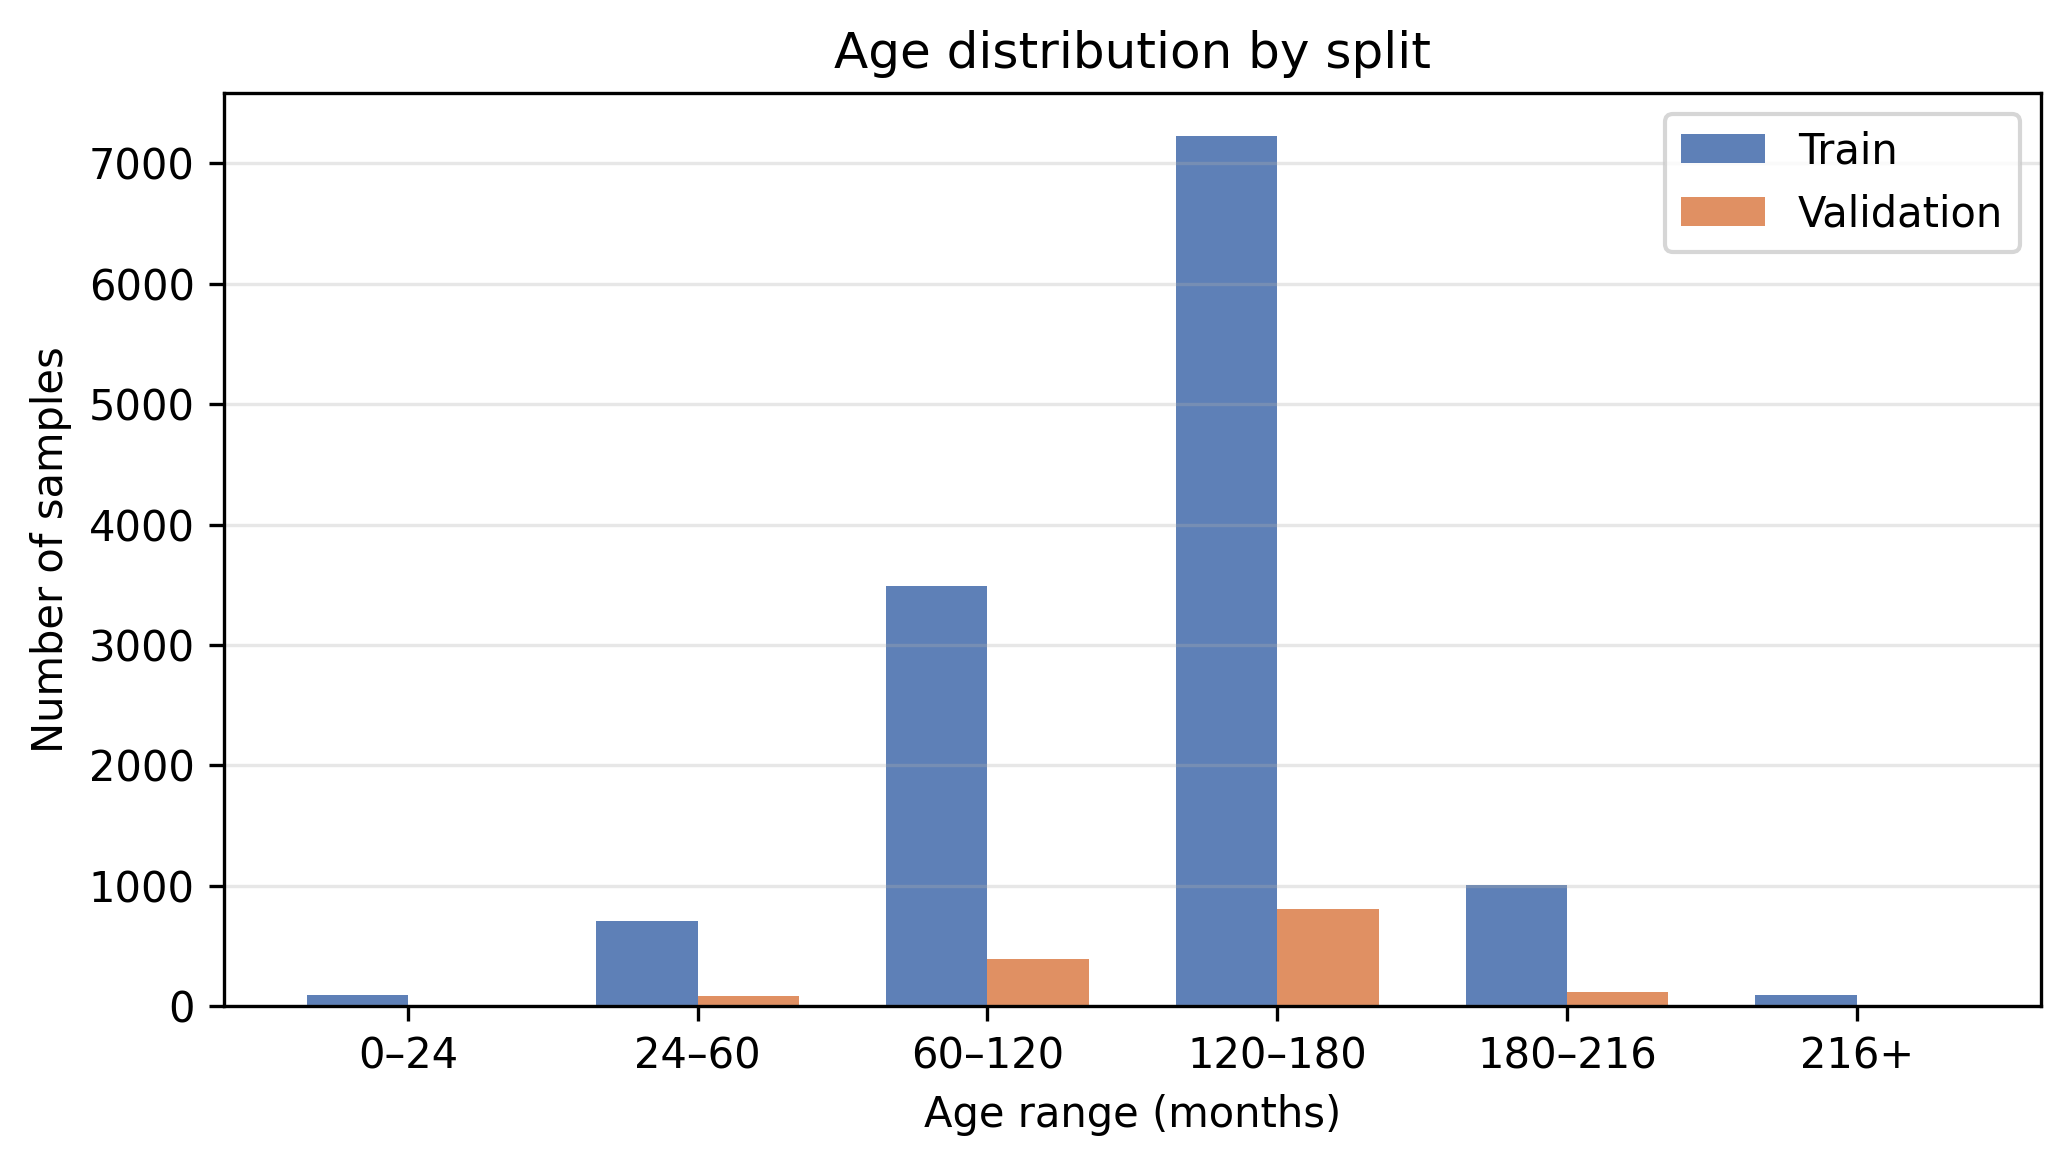

Saved: /kaggle/working/age_distribution.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import display, Image

def show_saved(path):
    assert os.path.exists(path), f"File not found: {path}"
    display(Image(filename=path))
    print("Saved:", path)

def describe_boneage(df: pd.DataFrame):
    y = df["boneage"].astype(float).values
    return {
        "n": int(len(y)),
        "mean": float(np.mean(y)),
        "std": float(np.std(y, ddof=1)),
        "median": float(np.median(y)),
        "min": float(np.min(y)),
        "max": float(np.max(y)),
    }

def gender_counts(df: pd.DataFrame):
    g = df["male"].astype(int).values
    n_male = int(np.sum(g == 1))
    n_female = int(np.sum(g == 0))
    n = int(len(g))
    return {
        "n": n,
        "male_count": n_male,
        "female_count": n_female,
        "male_pct": 100.0 * n_male / n if n else np.nan,
        "female_pct": 100.0 * n_female / n if n else np.nan,
    }

# Updated bins
BINS = [0, 24, 60, 120, 180, 216, 10**9]
LABELS = ["0–24", "24–60", "60–120", "120–180", "180–216", "216+"]

def age_bin_counts(df: pd.DataFrame, bins=BINS, labels=LABELS):
    y = df["boneage"].astype(float).values
    # digitize into bins
    idx = np.digitize(y, bins, right=False) - 1
    return {lab: int(np.sum(idx == i)) for i, lab in enumerate(labels)}

# Compute + print 
train_gender = gender_counts(train_df)
val_gender   = gender_counts(val_df)
train_age = describe_boneage(train_df)
val_age   = describe_boneage(val_df)

train_bins = age_bin_counts(train_df)
val_bins   = age_bin_counts(val_df)

print("=== Dataset size ===")
print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}\n")

print("=== Gender distribution ===")
print(f"Train: male {train_gender['male_count']} ({train_gender['male_pct']:.2f}%), "
      f"female {train_gender['female_count']} ({train_gender['female_pct']:.2f}%)")
print(f"Val:   male {val_gender['male_count']} ({val_gender['male_pct']:.2f}%), "
      f"female {val_gender['female_count']} ({val_gender['female_pct']:.2f}%)\n")

print("=== Bone age stats (months) ===")
print("Train:", {k: (round(v, 2) if isinstance(v, float) else v) for k, v in train_age.items()})
print("Val:  ", {k: (round(v, 2) if isinstance(v, float) else v) for k, v in val_age.items()}, "\n")

print("=== Age-bin counts ===")
print("Train bins:", train_bins)
print("Val bins:  ", val_bins)

# Age distribution plot 
bins = list(train_bins.keys())
train_counts = [train_bins[b] for b in bins]
val_counts   = [val_bins[b] for b in bins]

x = np.arange(len(bins))
width = 0.35

age_dist_path = "/kaggle/working/age_distribution.png"
plt.figure(figsize=(7,4))

c_train = PLOT_STYLE["model_colors"].get("M1_image_only", "tab:blue")
c_val   = PLOT_STYLE["model_colors"].get("M2_image_gender", "tab:orange")

plt.bar(x - width/2, train_counts, width, label="Train", color=c_train, alpha=0.9)
plt.bar(x + width/2, val_counts,   width, label="Validation", color=c_val, alpha=0.9)

plt.xticks(x, bins)
plt.ylabel("Number of samples")
plt.xlabel("Age range (months)")
plt.title("Age distribution by split")
plt.legend()
plt.grid(axis="y", alpha=PLOT_STYLE.get("grid_alpha", 0.25))
plt.tight_layout()
plt.savefig(age_dist_path, dpi=300, bbox_inches="tight")
plt.close()

show_saved(age_dist_path)


## 2) Target standardization (train statistics only)

In [5]:
y_mean = float(train_df["boneage"].mean())
y_std  = float(train_df["boneage"].std() + 1e-8)

Y_MIN = 0
Y_MAX = 240
NUM_BINS = Y_MAX - Y_MIN + 1


print("Target mean/std:", y_mean, y_std)

Target mean/std: 127.32075500488281 41.18158722923828


## 3) Image preprocessing (CLAHE + border mask + annotation inpaint)

In [6]:
IMG_SIZE = 256
BORDER_FRAC = 0.06
ANN_PCT = 99.7
CLAHE_CLIP = 2.0
CLAHE_TILE = 8
INPAINT_R = 3


def _clahe_and_mask_np(img):
    if hasattr(img, "numpy"):
        img = img.numpy()
    x = np.asarray(img)
    if x.ndim == 3:
        x = x[..., 0]
    if x.max() <= 1.5:
        x = x * 255.0
    x = np.clip(x, 0, 255).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=(CLAHE_TILE, CLAHE_TILE))
    x = clahe.apply(x)

    h, w = x.shape
    b = int(min(h, w) * BORDER_FRAC)
    if b > 0:
        x[:b, :] = 0
        x[-b:, :] = 0
        x[:, :b] = 0
        x[:, -b:] = 0

    thr = np.percentile(x, ANN_PCT)
    mask = (x >= thr).astype(np.uint8) * 255
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    x = cv2.inpaint(x, mask, inpaintRadius=INPAINT_R, flags=cv2.INPAINT_TELEA)
    return x[..., None].astype(np.float32)


def preprocess_image(path: tf.Tensor) -> tf.Tensor:
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")
    img = tf.py_function(_clahe_and_mask_np, [img], Tout=tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img


## 4) Pixel stats (train only) for normalization


In [ ]:
def compute_tissue_statistics(df, sample_size=2000, threshold=10.0):
    """
    Computes the Mean and Std of the training images, IGNORING the black background.
    """
    print(f"Computing tissue statistics on {sample_size} training samples...")
    
    # random sample to be fast but accurate
    sample_df = df.sample(n=min(len(df), sample_size), random_state=SEED)
    paths = sample_df["path"].values
    
    # Accumulators
    pixel_sum = 0.0
    pixel_sq_sum = 0.0
    pixel_count = 0
    
    for path in tqdm(paths):
        # Load & Preprocess
        img = preprocess_image(path).numpy()
        
        # MASKING 
        mask = img > threshold
        
        # Select only the tissue pixels
        tissue_pixels = img[mask]
        
        if len(tissue_pixels) > 0:
            count = len(tissue_pixels)
            pixel_sum += np.sum(tissue_pixels)
            pixel_sq_sum += np.sum(tissue_pixels ** 2)
            pixel_count += count
            
    # Calculate Global Mean & Std
    total_mean = pixel_sum / pixel_count
    total_var = (pixel_sq_sum / pixel_count) - (total_mean ** 2)
    total_std = np.sqrt(total_var)
    
    return float(total_mean), float(total_std)


# X_MEAN, X_STD = compute_tissue_statistics(train_df)

In [ ]:
X_MEAN = 68.8531
X_STD = 55.3605

print(f"Pixel mean/std (LOCKED): {X_MEAN}, {X_STD}")

Pixel mean/std (LOCKED): 68.8531, 55.3605


I0000 00:00:1770470228.686465      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770470228.692504      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


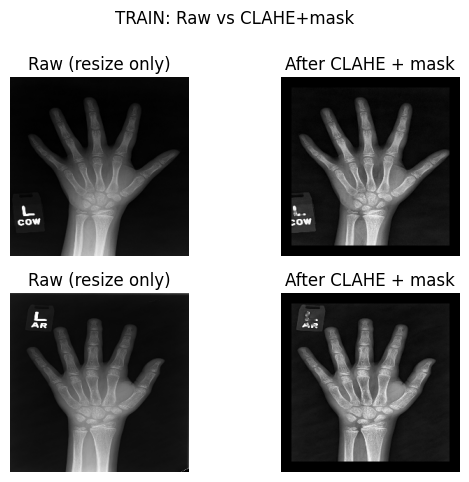

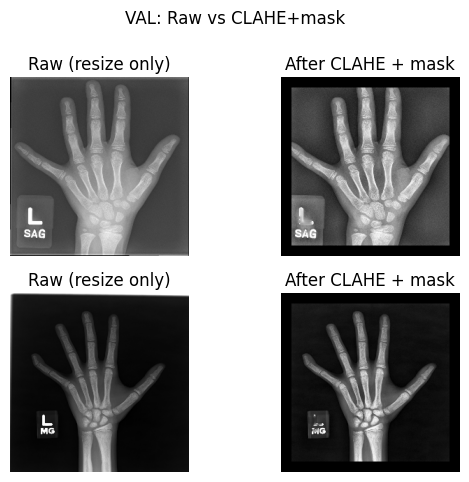

In [9]:
# Sanity check: BEFORE vs AFTER preprocessing

def load_raw_image(path, img_size=IMG_SIZE):
    """Raw: decode + resize only (no CLAHE, no masking). Returns float32 (H,W,1) in [0,255]."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [img_size, img_size], method="bilinear")
    return tf.cast(img, tf.float32)

def to_uint8(img_01_or_255):
    """Convert float image to uint8 for display; handles [0,1] or [0,255]."""
    x = img_01_or_255
    x = np.asarray(x)
    if x.max() <= 1.5:
        x = x * 255.0
    x = np.clip(x, 0, 255).astype(np.uint8)
    return x

def show_before_after(df, n=3, seed=SEED, title="Preprocessing sanity check"):
    """
    Shows n examples: raw vs preprocessed (CLAHE + mask).
    """
    assert "path" in df.columns, "df must contain a 'path' column"
    sample = df.sample(n=n, random_state=seed).reset_index(drop=True)

    fig, axes = plt.subplots(n, 2, figsize=(6, 2.4*n))
    fig.suptitle(title, y=0.995)

    for i, p in enumerate(sample["path"].values):
        raw = load_raw_image(p).numpy()
        pre = preprocess_image(tf.constant(p)).numpy()

        raw_u8 = to_uint8(raw[..., 0])
        pre_u8 = to_uint8(pre[..., 0])

        ax0 = axes[i, 0] if n > 1 else axes[0]
        ax1 = axes[i, 1] if n > 1 else axes[1]

        ax0.imshow(raw_u8, cmap="gray")
        ax0.set_title("Raw (resize only)")
        ax0.axis("off")

        ax1.imshow(pre_u8, cmap="gray")
        ax1.set_title("After CLAHE + mask")
        ax1.axis("off")

    plt.tight_layout()
    plt.show()


show_before_after(train_df, n=2, title="TRAIN: Raw vs CLAHE+mask")
show_before_after(val_df,   n=2, title="VAL: Raw vs CLAHE+mask")

## 5) Model configurations (M1–M4)
#### Config dataclass

In [10]:
@dataclass
class ExperimentConfig:
    name: str
    use_gender: bool
    use_patches: bool
    fusion_type: str            # 'learned' | 'gated' | 'none' (for whole image)
    img_size: int = 256
    patch_size: int = 128
    patch_stride: int = 64
    batch_size: int = 16
    epochs: int = 25
    lr: float = 3e-4
    ckpt_path: str = ""

CONFIGS = {
    "M1": ExperimentConfig("M1_image_only", False, False, "none", ckpt_path="/kaggle/working/m1_best.keras"),
    "M2": ExperimentConfig("M2_image_gender", True,  False, "none", ckpt_path="/kaggle/working/m2_best.keras"),
    "M3":ExperimentConfig("M3_patches_gated_gender",   True, True,  "gated",   ckpt_path="/kaggle/working/m3_best.keras"),
    "M4": ExperimentConfig("M4_patches_learned_gender", True, True,  "learned", ckpt_path="/kaggle/working/m4_best.keras"),
}

# Choose which experiments to run
experiments = ["M1", "M2", "M3", "M4"]

# 6) Augmentation

In [ ]:
def augment_patches_tensor(patches):
    # Flip 
    patches = tf.image.random_flip_left_right(patches)
    
    # Rotation
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    patches = tf.image.rot90(patches, k)
    
    # Intensity
    patches = tf.image.random_brightness(patches, max_delta=0.08)
    patches = tf.image.random_contrast(patches, 0.92, 1.08)
    patches = patches + tf.random.normal(tf.shape(patches), stddev=0.02)
    return patches

def augment_image_tensor(img):
    # Flip
    img = tf.image.random_flip_left_right(img)
    
    # Rotation
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    
    # Intensity
    img = tf.image.random_brightness(img, max_delta=0.08)
    img = tf.image.random_contrast(img, 0.92, 1.08)
    img = img + tf.random.normal(tf.shape(img), stddev=0.02)
    return img

## 7) tf.data pipeline (cache in RAM)


In [ ]:
def num_patches(cfg: ExperimentConfig) -> int:
    return ((cfg.img_size - cfg.patch_size) // cfg.patch_stride + 1) ** 2


def extract_patches(img: tf.Tensor, patch_size: int, stride: int) -> tf.Tensor:
    img4 = tf.expand_dims(img, 0)
    patches = tf.image.extract_patches(
        images=img4,
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, stride, stride, 1],
        rates=[1, 1, 1, 1],
        padding="VALID",
    )
    
    return tf.reshape(patches, [-1, patch_size, patch_size, 1])


def make_dataset(df: pd.DataFrame, cfg: ExperimentConfig, training: bool) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices((df["path"].values, df["male"].values, df["boneage"].values))

    if training:
        ds = ds.shuffle(2048, seed=SEED, reshuffle_each_iteration=True)

    P = num_patches(cfg) if cfg.use_patches else None

    def base_map(path, gender, age):
        img = preprocess_image(path)
        if cfg.img_size != IMG_SIZE:
            img = tf.image.resize(img, [cfg.img_size, cfg.img_size], method="bilinear")
        img = (img - X_MEAN) / X_STD

        x = {}
        if cfg.use_patches:
            patches = extract_patches(img, cfg.patch_size, cfg.patch_stride)
            patches = tf.ensure_shape(patches, [P, cfg.patch_size, cfg.patch_size, 1])
            x["patches"] = patches
        else:
            img = tf.ensure_shape(img, [cfg.img_size, cfg.img_size, 1])
            x["img"] = img

        if cfg.use_gender:
            x["gender"] = tf.reshape(gender, [1])

        # y is months
        y = tf.cast(age, tf.float32)
        return x, y

    # Deterministic base mapping for both train and val
    ds = ds.map(base_map, num_parallel_calls=AUTOTUNE).cache()

    # Augment AFTER cache
    if training:
        def aug_map(x, y):
            x = dict(x)
            if cfg.use_patches:
                x["patches"] = tf.ensure_shape(augment_patches_tensor(x["patches"]), [P, cfg.patch_size, cfg.patch_size, 1])
            else:
                x["img"] = tf.ensure_shape(augment_image_tensor(x["img"]), [cfg.img_size, cfg.img_size, 1])
            return x, y

        ds = ds.map(aug_map, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(cfg.batch_size).prefetch(AUTOTUNE)
    return ds

# 8) DLDL loss + expectation MAE

In [13]:
class DLDLLoss(tf.keras.losses.Loss):
    def __init__(self, min_age=Y_MIN, max_age=Y_MAX, sigma=4.0, name="dldl_loss"):
        super().__init__(name=name)
        self.bins = tf.range(min_age, max_age + 1, dtype=tf.float32)  # [241]
        self.sigma = tf.constant(float(sigma), tf.float32)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_true = tf.reshape(y_true, [-1, 1])  # [B,1]

        grid = tf.expand_dims(self.bins, 0)   # [1,241]
        dist = tf.exp(-tf.square(grid - y_true) / (2.0 * self.sigma ** 2))
        dist = dist / (tf.reduce_sum(dist, axis=1, keepdims=True) + 1e-8)

        return tf.keras.losses.categorical_crossentropy(dist, y_pred, from_logits=True)


class DLDLMAE(tf.keras.metrics.Metric):
    def __init__(self, min_age=Y_MIN, max_age=Y_MAX, name="mae_months", **kw):
        super().__init__(name=name, **kw)
        self.mae = tf.keras.metrics.MeanAbsoluteError()
        self.bins = tf.range(min_age, max_age + 1, dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        probs = tf.nn.softmax(y_pred, axis=1)
        pred_months = tf.reduce_sum(probs * self.bins, axis=1)
        self.mae.update_state(y_true, pred_months)

    def result(self):
        return self.mae.result()

    def reset_states(self):
        self.mae.reset_states()

## 9) Models: CNN encoder + learned attention + gated attention

In [14]:
def build_encoder(input_shape):
    inp = tf.keras.Input(shape=input_shape)
    x = inp

    # Block 1
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Block 3
    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Block 4
    x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    return tf.keras.Model(inp, x, name="patch_encoder_v2")


# gated attention: compute weights from (tanh * sigmoid), apply to ORIGINAL inputs 
class GatedAttention(tf.keras.layers.Layer):
    def __init__(self, hidden_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
        self.v_dense = tf.keras.layers.Dense(hidden_dim, activation="tanh", name="attn_v")
        self.u_dense = tf.keras.layers.Dense(hidden_dim, activation="sigmoid", name="attn_u_gate")
        self.w_dense = tf.keras.layers.Dense(1, name="attn_w")

    def call(self, inputs):
        # inputs: [B, P, D]
        v = self.v_dense(inputs)                 # [B,P,H]
        u = self.u_dense(inputs)                 # [B,P,H]
        gated = v * u                            # [B,P,H]
        scores = self.w_dense(gated)             # [B,P,1]
        weights = tf.nn.softmax(scores, axis=1)  # [B,P,1]
        output = tf.reduce_sum(inputs * weights, axis=1)  # [B,D]
        return output


def build_model(cfg: ExperimentConfig) -> tf.keras.Model:
    inputs = {}

    # Whole-image models (M1/M2)
    if not cfg.use_patches:
        img_in = tf.keras.Input(shape=(cfg.img_size, cfg.img_size, 1), name="img")
        inputs["img"] = img_in

        enc = build_encoder((cfg.img_size, cfg.img_size, 1))
        x = enc(img_in)

        if cfg.use_gender:
            g_in = tf.keras.Input(shape=(1,), name="gender")
            inputs["gender"] = g_in
            # gender embedding
            g_embed = tf.keras.layers.Dense(32, activation="relu")(g_in)
            x = tf.keras.layers.Concatenate()([x, g_embed])

        x = tf.keras.layers.Dense(256, activation="relu")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(0.5)(x)

        out = tf.keras.layers.Dense(NUM_BINS, activation=None, dtype="float32", name="age_logits")(x)
        return tf.keras.Model(inputs=inputs, outputs=out, name=cfg.name)

    # Patch models (M3 gated / M4 learned )
    P = num_patches(cfg)
    patches_in = tf.keras.Input(shape=(P, cfg.patch_size, cfg.patch_size, 1), name="patches")
    inputs["patches"] = patches_in

    enc = build_encoder((cfg.patch_size, cfg.patch_size, 1))
    feats = tf.keras.layers.TimeDistributed(enc, name="td_encoder")(patches_in)  # [B,P,D]

    if cfg.fusion_type == "learned":
        scores = tf.keras.layers.Dense(1, name="attn_score")(feats)                 # [B,P,1]
        weights = tf.keras.layers.Softmax(axis=1, name="attn_softmax")(scores)      # [B,P,1]
        x = tf.keras.layers.Dot(axes=1, name="attn_weighted_sum")([weights, feats]) # [B,1,D]
        x = tf.keras.layers.Flatten(name="attn_flatten")(x)                         # [B,D]
    elif cfg.fusion_type == "gated":
        x = GatedAttention(hidden_dim=128, name="gated_attention")(feats)        # [B,D]
    else:
        raise ValueError("fusion_type must be 'learned' or 'gated'")

    if cfg.use_gender:
        g_in = tf.keras.Input(shape=(1,), name="gender")
        inputs["gender"] = g_in
      
        g_embed = tf.keras.layers.Dense(32, activation="relu")(g_in)
        x = tf.keras.layers.Concatenate()([x, g_embed])

    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    out = tf.keras.layers.Dense(NUM_BINS, activation=None, dtype="float32", name="age_logits")(x)
    return tf.keras.Model(inputs=inputs, outputs=out, name=cfg.name)

# 10) Utility: inference timing

In [15]:
def measure_inference_time_ms(model: tf.keras.Model, sample_batch: dict, n_warmup=10, n_runs=50) -> float:
    for _ in range(n_warmup):
        _ = model(sample_batch, training=False)
    t0 = time.time()
    for _ in range(n_runs):
        _ = model(sample_batch, training=False)
    t1 = time.time()
    bs = list(sample_batch.values())[0].shape[0]
    return float(((t1 - t0) / n_runs) * 1000.0 / bs)

## 11) Training, evaluation, timing utilities
#### Utilities + training runner

In [16]:
def run_experiment(cfg: ExperimentConfig):
    print(f"=== Running {cfg.name} ===")

    train_ds = make_dataset(train_df, cfg, training=True)
    val_ds   = make_dataset(val_df,   cfg, training=False)

    model = build_model(cfg)

    steps_per_epoch = int(np.ceil(len(train_df) / cfg.batch_size))
    total_steps = steps_per_epoch * cfg.epochs

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=cfg.lr,
        decay_steps=total_steps,
        alpha=0.01
    )

    opt = tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=1e-3,
        clipnorm=1.0
    )

    model.compile(
        optimizer=opt,
        loss=DLDLLoss(min_age=Y_MIN, max_age=Y_MAX, sigma=4.0),
        metrics=[DLDLMAE(min_age=Y_MIN, max_age=Y_MAX)]
    )

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            cfg.ckpt_path,
            monitor="val_mae_months",
            mode="min",
            save_best_only=True
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_mae_months",
            mode="min",
            patience=10,
            restore_best_weights=True,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.epochs,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate best checkpoint
    best = tf.keras.models.load_model(
        cfg.ckpt_path,
        custom_objects={
            "DLDLLoss": DLDLLoss,
            "DLDLMAE": DLDLMAE,
            "GatedAttention": GatedAttention,
        },
        compile=False
    )

    logits = best.predict(val_ds, verbose=0)
    probs = tf.nn.softmax(logits, axis=1).numpy()
    bins = np.arange(Y_MIN, Y_MAX + 1, dtype=np.float32)
    y_pred = (probs * bins[None, :]).sum(axis=1)

    y_true = val_df["boneage"].values.astype(np.float32)
    mae = float(np.mean(np.abs(y_pred - y_true)))

    params = int(best.count_params())
    x_batch = next(iter(val_ds))[0]
    ms_per_img = measure_inference_time_ms(best, x_batch)

    print(f"{cfg.name} | BEST Val MAE: {mae:.2f} months | params={params:,} | ms/img={ms_per_img:.3f}")

    return {
        "name": cfg.name,
        "val_mae_months": mae,
        "params": params,
        "ms_per_img": ms_per_img,
        "history": history,
    }

## 12) Train and evaluate models (M1–M4)
#### Run M1–M4 and save summary

In [17]:
experiments = ["M1", "M2", "M3", "M4"]

results = {}
for key in experiments:
    results[key] = run_experiment(CONFIGS[key])

histories = {results[k]["name"]: results[k]["history"] for k in results}

summary_rows = []
for k in experiments:
    r = results[k]
    summary_rows.append({
        "model": r["name"],
        "val_mae_months": r["val_mae_months"],
        "params": r["params"],
        "ms_per_img": r["ms_per_img"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("val_mae_months")
print(summary_df)

summary_csv = "/kaggle/working/summary_results.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)


=== Running M1_image_only ===
Epoch 1/25


I0000 00:00:1770470238.575328      68 service.cc:152] XLA service 0x7f55900982e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770470238.575364      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770470238.575369      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770470240.493950      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-07 13:17:31.865224: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv %cudnn-conv-bw-filter.8 = (f16[32,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[16,256,256,32]{3,2,1,0} %bitcast.13588, f16[16,256,256,32]{3,2,1,0} %bitcast.13609), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/M1_image_only_1/patch_encoder_v2_1/conv2d_1_2/convoluti

  3/789 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - loss: 6.3921 - mae_months: 42.2155

I0000 00:00:1770470263.564528      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


789/789 ━━━━━━━━━━━━━━━━━━━━ 267s 300ms/step - loss: 5.9487 - mae_months: 35.2707 - val_loss: 5.8653 - val_mae_months: 29.1589
Epoch 2/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - loss: 5.2852 - mae_months: 28.0882 - val_loss: 6.4696 - val_mae_months: 50.0633
Epoch 3/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - loss: 5.0279 - mae_months: 25.4911 - val_loss: 4.8164 - val_mae_months: 24.4117
Epoch 4/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - loss: 4.8726 - mae_months: 23.7725 - val_loss: 5.4594 - val_mae_months: 33.4369
Epoch 5/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - loss: 4.7509 - mae_months: 22.1686 - val_loss: 4.4657 - val_mae_months: 18.8693
Epoch 6/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - loss: 4.6452 - mae_months: 20.4331 - val_loss: 4.8902 - val_mae_months: 23.3478
Epoch 7/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - loss: 4.5660 - mae_months: 19.0273 - val_loss: 4.3665 - val_mae_months: 15.9379
Epoch 8/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - l

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'gated_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


M3_patches_gated_gender | BEST Val MAE: 8.81 months | params=786,450 | ms/img=12.828
=== Running M4_patches_learned_gender ===
Epoch 1/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 279s 317ms/step - loss: 5.9228 - mae_months: 35.0611 - val_loss: 5.5648 - val_mae_months: 33.8828
Epoch 2/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - loss: 5.1381 - mae_months: 27.7330 - val_loss: 4.5876 - val_mae_months: 18.3771
Epoch 3/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - loss: 4.7186 - mae_months: 20.1068 - val_loss: 4.3089 - val_mae_months: 14.2416
Epoch 4/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - loss: 4.4826 - mae_months: 16.5340 - val_loss: 4.2632 - val_mae_months: 13.7936
Epoch 5/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 67s 84ms/step - loss: 4.3343 - mae_months: 14.5944 - val_loss: 4.1128 - val_mae_months: 11.8142
Epoch 6/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 67s 84ms/step - loss: 4.2390 - mae_months: 13.5127 - val_loss: 4.0426 - val_mae_months: 11.5308
Epoch 7/25
789/789 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step -

## Ensemble (Probability Averaging)

We combine complementary models (whole-image and patch-based) using a weighted
probability-level ensemble. Model weights are set proportional to the inverse
validation MAE, and final age predictions are obtained via expectation over the
age distribution.


In [18]:
BINS = np.arange(Y_MIN, Y_MAX + 1, dtype=np.float32)  # [241]


def get_probs(model_path: str, config_key: str, df: pd.DataFrame) -> np.ndarray:
    """
    Load a trained model and return probabilities over age bins for df.
    """
    print(f"\n--- Processing {config_key} ---")
    cfg = CONFIGS[config_key]

    print(f"Loading model from: {model_path}")
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            "DLDLLoss": DLDLLoss,
            "DLDLMAE": DLDLMAE,
            "GatedAttention": GatedAttention,
        },
        compile=False,
    )

    # Fresh DS per model (patch vs img shapes)
    ds = make_dataset(df, cfg, training=False)

    print("Generating logits...")
    logits = model.predict(ds, verbose=1)  # [N,241]

    if logits.ndim != 2 or logits.shape[1] != len(BINS):
        raise ValueError(f"Unexpected logits shape: {logits.shape}, expected [N,{len(BINS)}]")

    probs = tf.nn.softmax(logits, axis=1).numpy().astype(np.float32)  # [N,241]
    return probs


def probs_to_months(probs: np.ndarray) -> np.ndarray:
    """Expectation decoding: y_hat = sum_i p(i)*i."""
    if probs.ndim != 2 or probs.shape[1] != len(BINS):
        raise ValueError(f"Unexpected probs shape: {probs.shape}")
    return (probs * BINS[None, :]).sum(axis=1)


def compute_mae(pred_months: np.ndarray, true_months: np.ndarray) -> float:
    pred_months = pred_months.astype(np.float32)
    true_months = true_months.astype(np.float32)
    return float(np.mean(np.abs(pred_months - true_months)))

In [19]:
root = "/kaggle/working/"
paths = {
    "M2": root + "/m2_best.keras",
    "M4": root + "/m4_best.keras",
    "M3": root + "/m3_best.keras",
}

# Load probs for each model
probs_m2 = get_probs(paths["M2"], "M2", val_df)
probs_m4 = get_probs(paths["M4"], "M4", val_df)
probs_m3 = get_probs(paths["M3"], "M3", val_df)

# Load per-model MAEs from summary CSV 
summary_path = root + "/summary_results.csv"
summary_df = pd.read_csv(summary_path)

ensemble_model_names = [
    CONFIGS["M2"].name,
    CONFIGS["M4"].name,
    CONFIGS["M3"].name,
]

ens_df = summary_df[summary_df["model"].isin(ensemble_model_names)].copy()

if len(ens_df) != len(ensemble_model_names):
    missing = set(ensemble_model_names) - set(ens_df["model"].tolist())
    raise ValueError(f"Missing models in summary CSV: {missing}")

# inverse-MAE weights
maes = ens_df.set_index("model").loc[ensemble_model_names, "val_mae_months"].values.astype(np.float32)
w = 1.0 / maes
w = w / w.sum()

weights_map = {ensemble_model_names[i]: float(w[i]) for i in range(len(w))}

print("\n--- 3-Way Ensemble (M2 + M3 + M4) ---")
for m in ensemble_model_names:
    print(f"{m:30s}  MAE={float(ens_df[ens_df['model']==m]['val_mae_months'].values[0]):.4f}  w={weights_map[m]:.4f}")

# Probability averaging 
avg_probs = (
    probs_m2 * weights_map[CONFIGS["M2"].name] +
    probs_m4 * weights_map[CONFIGS["M4"].name] +
    probs_m3 * weights_map[CONFIGS["M3"].name]
)

# Decode + MAE 
y_pred_months = probs_to_months(avg_probs)
y_true = val_df["boneage"].values.astype(np.float32)

mae_ens = compute_mae(y_pred_months, y_true)

print("\n=============================================")
print(f"3-Model Ensemble (M2 + M3 + M4): {mae_ens:.4f} months")
print("=============================================")



--- Processing M2 ---
Loading model from: /kaggle/working//m2_best.keras
Generating logits...
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 183ms/step

--- Processing M4 ---
Loading model from: /kaggle/working//m4_best.keras
Generating logits...
90/90 ━━━━━━━━━━━━━━━━━━━━ 24s 236ms/step

--- Processing M3 ---
Loading model from: /kaggle/working//m3_best.keras


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'gated_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Generating logits...
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 218ms/step

--- 3-Way Ensemble (M2 + M3 + M4) ---
M2_image_gender                 MAE=8.3606  w=0.3519
M4_patches_learned_gender       MAE=9.3670  w=0.3141
M3_patches_gated_gender         MAE=8.8104  w=0.3340

3-Model Ensemble (M2 + M3 + M4): 7.8426 months


# Report Figures
This section produces all plots used in the LaTeX report.


In [ ]:
def show_saved(path):
    assert os.path.exists(path), f"File not found: {path}"
    display(Image(filename=path))
    print("Saved:", path)

def predict_months_from_model(model_path: str, config_key: str, df: pd.DataFrame) -> np.ndarray:
    """
    Explicitly compute y_pred (months) for ONE model (config_key) on df.
    """
    cfg = CONFIGS[config_key]

    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            "DLDLLoss": DLDLLoss,
            "DLDLMAE": DLDLMAE,
            "GatedAttention": GatedAttention,
        },
        compile=False,
    )

    ds = make_dataset(df, cfg, training=False)  # no shuffle, no augmentation
    logits = model.predict(ds, verbose=0)       # [N,241]
    probs = tf.nn.softmax(logits, axis=1).numpy().astype(np.float32)
    y_pred_months = (probs * BINS[None, :]).sum(axis=1)
    return y_pred_months

def plot_learning_curves(
    histories,
    out_path,
    metric_key="mae_months",
    include=None,          # list of model names to include, or None = all
    exclude=None,          # list of model names to exclude
    title="Training/Validation MAE Curves",
    style=None,
    mark_best=True,
):
    if style is None:
        style = {
            "train_alpha": 0.85,
            "val_alpha": 0.95,
            "val_linestyle": "--",
            "grid_alpha": 0.25,
        }

    plt.figure(figsize=(10, 6))
    plotted_any = False

    for name, hist in histories.items():
        if hist is None or not hasattr(hist, "history"):
            continue

        if include is not None and name not in include:
            continue
        if exclude is not None and name in exclude:
            continue

        h = hist.history
        train_key = metric_key
        val_key = f"val_{metric_key}"

        if train_key not in h or val_key not in h:
            continue

        y_train = np.array(h[train_key], dtype=np.float32)
        y_val   = np.array(h[val_key], dtype=np.float32)
        epochs  = np.arange(1, len(y_train) + 1)

        c = _get_model_color(name, PLOT_STYLE) if "_get_model_color" in globals() else None

        plt.plot(epochs, y_train, label=f"{name} train", color=c, alpha=style["train_alpha"])
        plt.plot(epochs, y_val,   label=f"{name} val",   color=c,
                 linestyle=style["val_linestyle"], alpha=style["val_alpha"])

        if mark_best and len(y_val) > 0:
            best_idx = int(np.argmin(y_val))
            plt.scatter(epochs[best_idx], y_val[best_idx], color=c, s=30, zorder=3)

        plotted_any = True

    if not plotted_any:
        raise ValueError("No curves plotted. Check 'include/exclude' names and metric keys.")

    plt.xlabel("Epoch")
    plt.ylabel("MAE (months)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=style["grid_alpha"])
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()
    print("Saved:", out_path)

def plot_model_bar(results_df, out_path="/kaggle/working/model_mae_bar.png", style=PLOT_STYLE):
    """
    results_df columns:
      - model (string) e.g., "M4_patches_learned_gender"
      - val_mae_months (float)
    """
    df = results_df.copy().sort_values("val_mae_months", ascending=True)

    # Create short labels: M1/M2/... inferred from name prefix if present
    def short_label(name):
        if name.startswith("M") and len(name) >= 2 and name[1].isdigit():
            return name.split("_")[0]  # "M2"
        return name

    labels = [short_label(m) for m in df["model"].tolist()]
    maes   = df["val_mae_months"].astype(float).tolist()
    colors = [_get_model_color(m, style) for m in df["model"].tolist()]

    plt.figure(figsize=(7.5, 4.8))
    bars = plt.bar(labels, maes, color=colors)

    plt.ylabel("Best Validation MAE (months)")
    plt.title("Model Comparison (Validation MAE)")
    plt.grid(True, axis="y", alpha=style["grid_alpha"])

    # annotate values
    for b, v in zip(bars, maes):
        plt.text(
            b.get_x() + b.get_width() / 2,
            v + 0.05,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()
    print("Saved:", out_path)

def run_error_analysis_for_model(model_path: str, config_key: str, df: pd.DataFrame, out_prefix: str):
    """
    End-to-end: predict months for model config_key, then plot error analysis.
    """
    y_true = df["boneage"].values.astype(np.float32)
    genders = df["male"].values  # can be 0/1/bool; function handles it

    y_pred = predict_months_from_model(model_path, config_key, df)

    return error_analysis_plots(
        y_true=y_true,
        y_pred=y_pred,
        genders=genders,
        out_prefix=out_prefix,
        style=PLOT_STYLE
    )
    
def error_analysis_plots(y_true, y_pred, genders, out_prefix="/kaggle/working/m2", style=PLOT_STYLE):
    import numpy as np
    import matplotlib.pyplot as plt

    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    genders = np.asarray(genders)

    abs_err = np.abs(y_pred - y_true)

    # Robust gender handling: accept {0,1}, {False,True}, floats
    male_mask = (genders.astype(np.float32) >= 0.5)
    female_mask = ~male_mask

    def safe_mean(x):
        return float(np.mean(x)) if x.size > 0 else np.nan

    mae_male = safe_mean(abs_err[male_mask])
    mae_female = safe_mean(abs_err[female_mask])

    # MAE by Gender
    plt.figure(figsize=(5.0, 4.0))
    vals = [mae_female, mae_male]
    labs = ["female", "male"]
    cols = [style["gender_colors"]["female"], style["gender_colors"]["male"]]

    plt.bar(labs, vals, color=cols)
    plt.ylabel("MAE (months)")
    plt.title("MAE by Gender")
    plt.grid(True, axis="y", alpha=style.get("grid_alpha", 0.25))
    plt.tight_layout()
    p1 = f"{out_prefix}_mae_by_gender.png"
    plt.savefig(p1, dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", p1)

    # MAE by Age Bin
    bin_edges = np.array([0, 24, 60, 120, 180, 216, 10**9], dtype=np.float32)
    bin_labels = ["0–24", "24–60", "60–120", "120–180", "180–216", "216+"]

    idx = np.digitize(y_true, bin_edges, right=False) - 1 

    maes = []
    for i in range(len(bin_labels)):
        m = (idx == i)
        maes.append(safe_mean(abs_err[m]))

    plt.figure(figsize=(7.0, 4.0))
    plt.bar(bin_labels, maes, color=style["bins_color"])
    plt.ylabel("MAE (months)")
    plt.title("MAE by Age Bin")
    plt.grid(True, axis="y", alpha=style.get("grid_alpha", 0.25))
    plt.tight_layout()
    p2 = f"{out_prefix}_mae_by_age_bins.png"
    plt.savefig(p2, dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", p2)

    return {"mae_female": mae_female, "mae_male": mae_male, "mae_bins": maes, "bin_labels": bin_labels}


## Learning curves (train vs validation MAE)


Saved: /kaggle/working/learning_curves_all.png


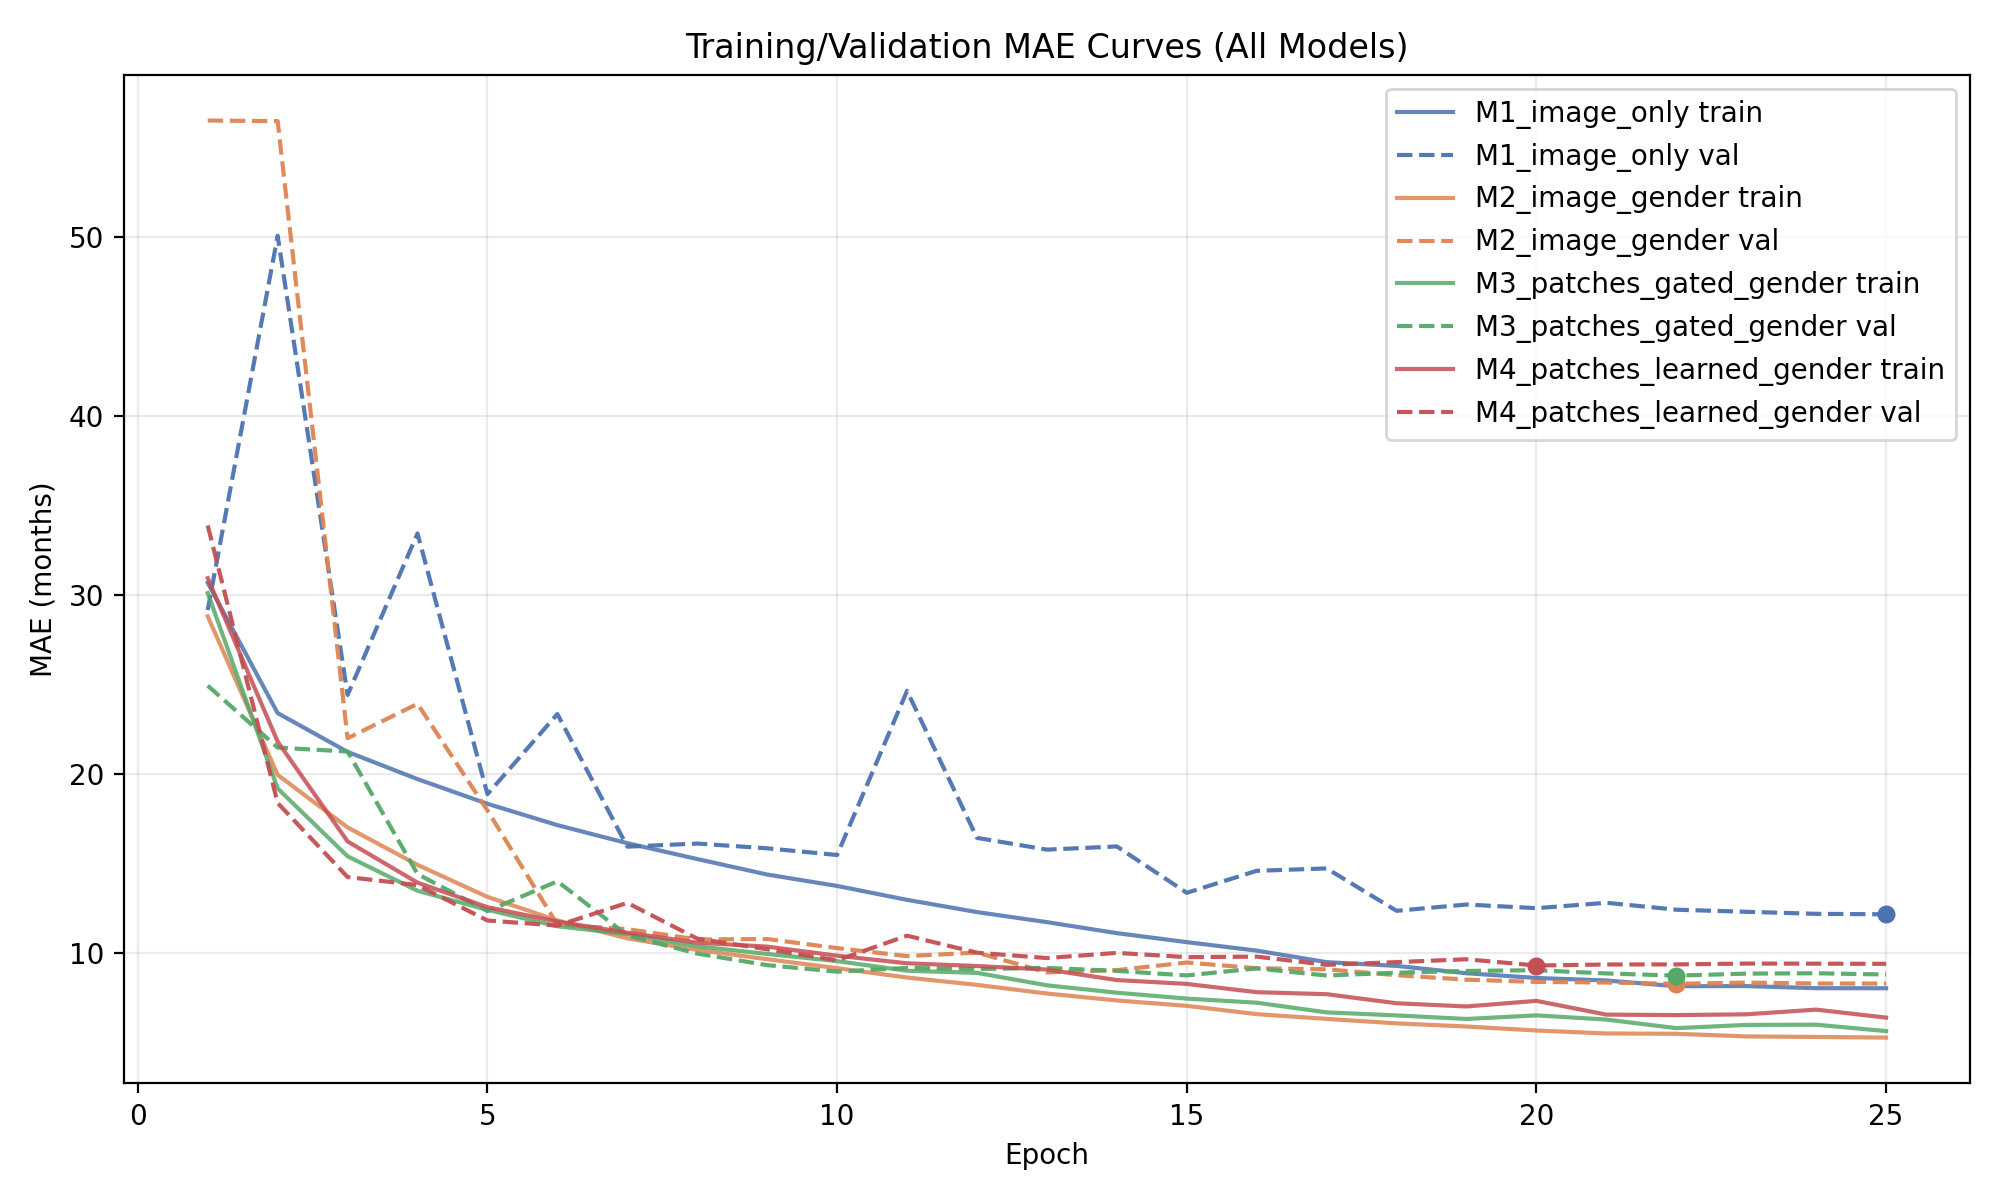

Saved: /kaggle/working/learning_curves_all.png


In [21]:
path_all = "/kaggle/working/learning_curves_all.png"
plot_learning_curves(
    histories,
    out_path=path_all,
    metric_key="mae_months",
    title="Training/Validation MAE Curves (All Models)",
    mark_best=True,
)
show_saved(path_all)


Saved: /kaggle/working/learning_curves_M2_vs_M4.png


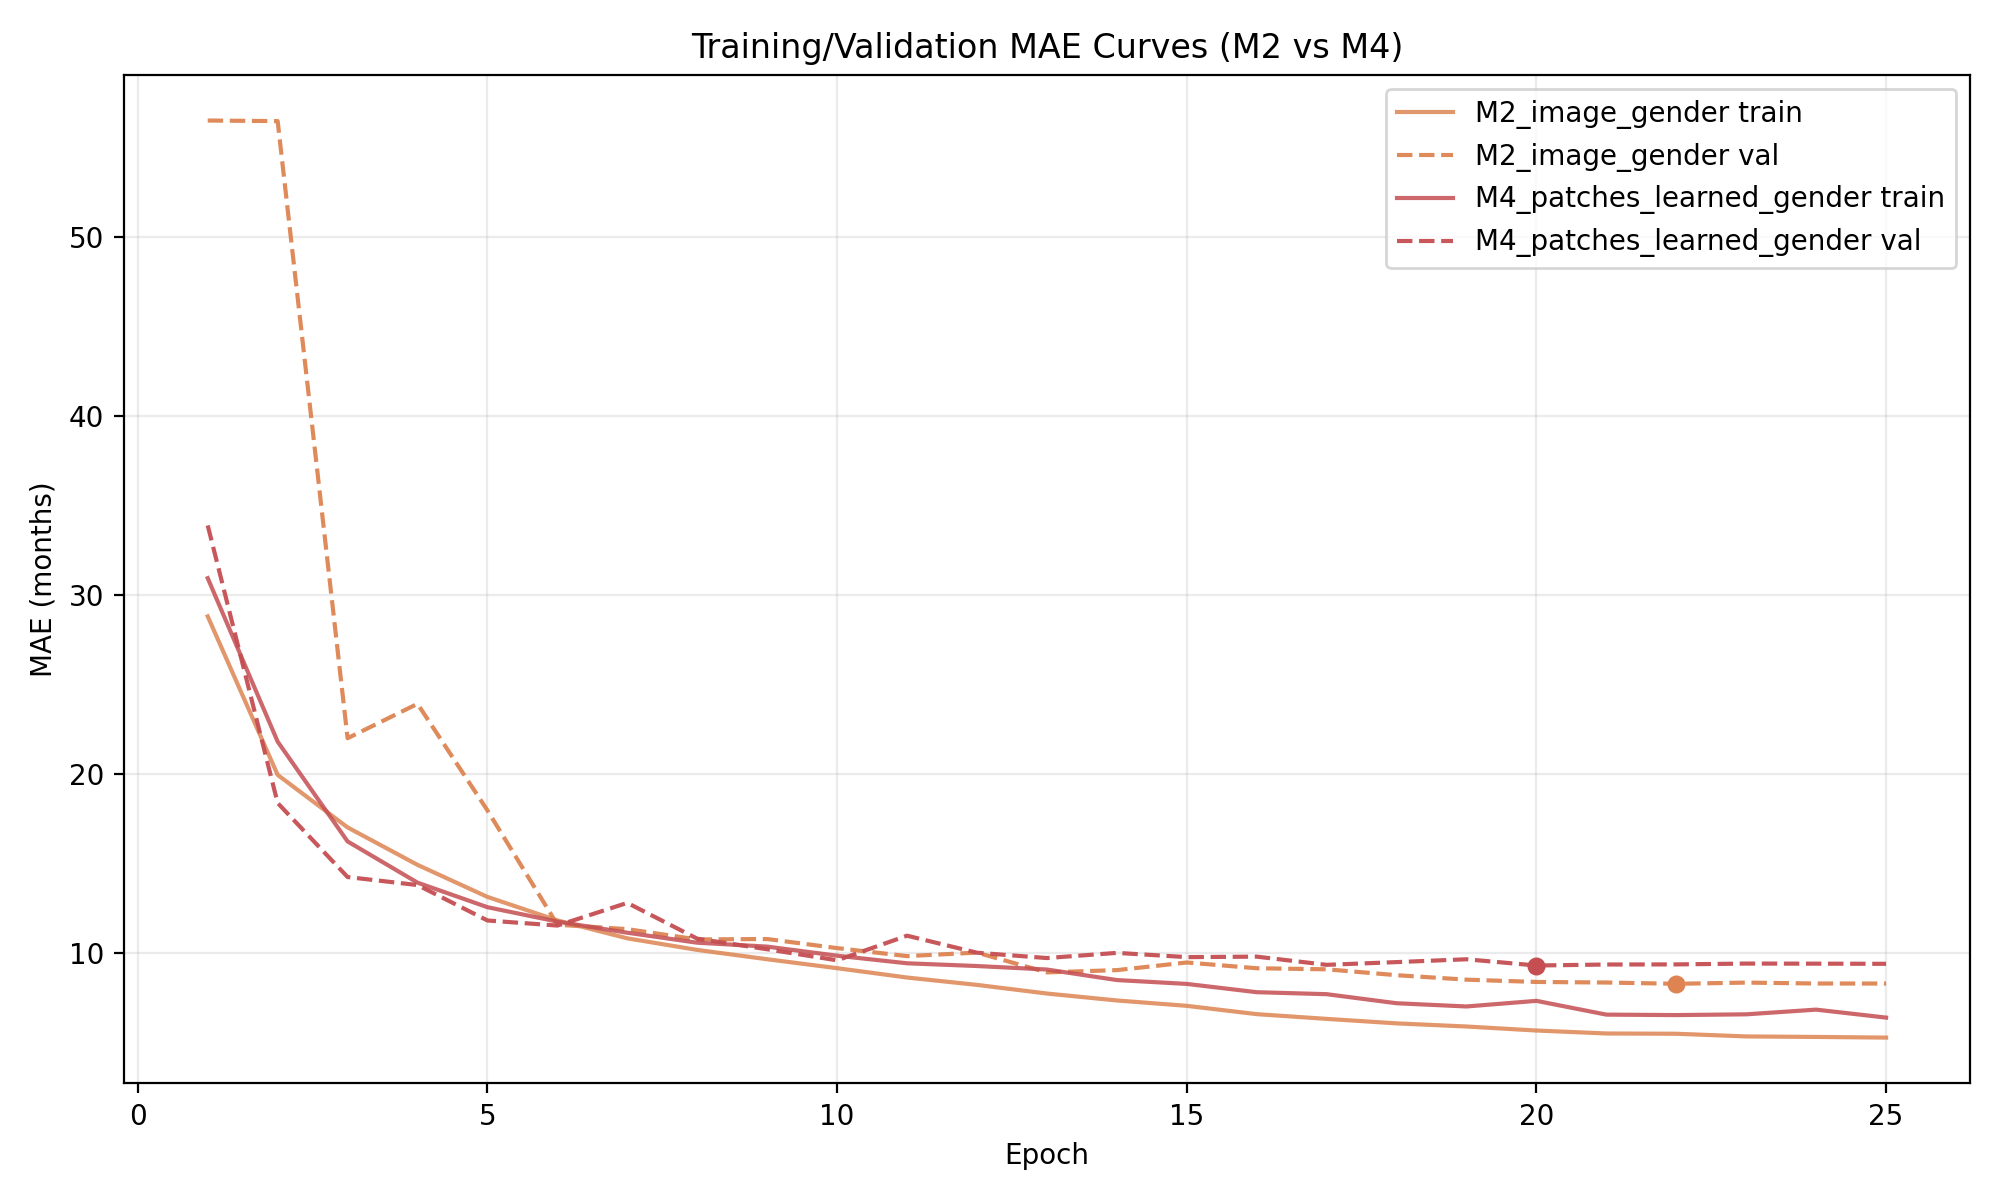

Saved: /kaggle/working/learning_curves_M2_vs_M4.png


In [22]:
path_m2_m4 = "/kaggle/working/learning_curves_M2_vs_M4.png"
plot_learning_curves(
    histories,
    out_path=path_m2_m4,
    metric_key="mae_months",
    include=["M2_image_gender", "M4_patches_learned_gender"],
    title="Training/Validation MAE Curves (M2 vs M4)",
    mark_best=True,
)
show_saved(path_m2_m4)


## Model comparison (Validation MAE)

Saved: /kaggle/working/model_mae_bar.png


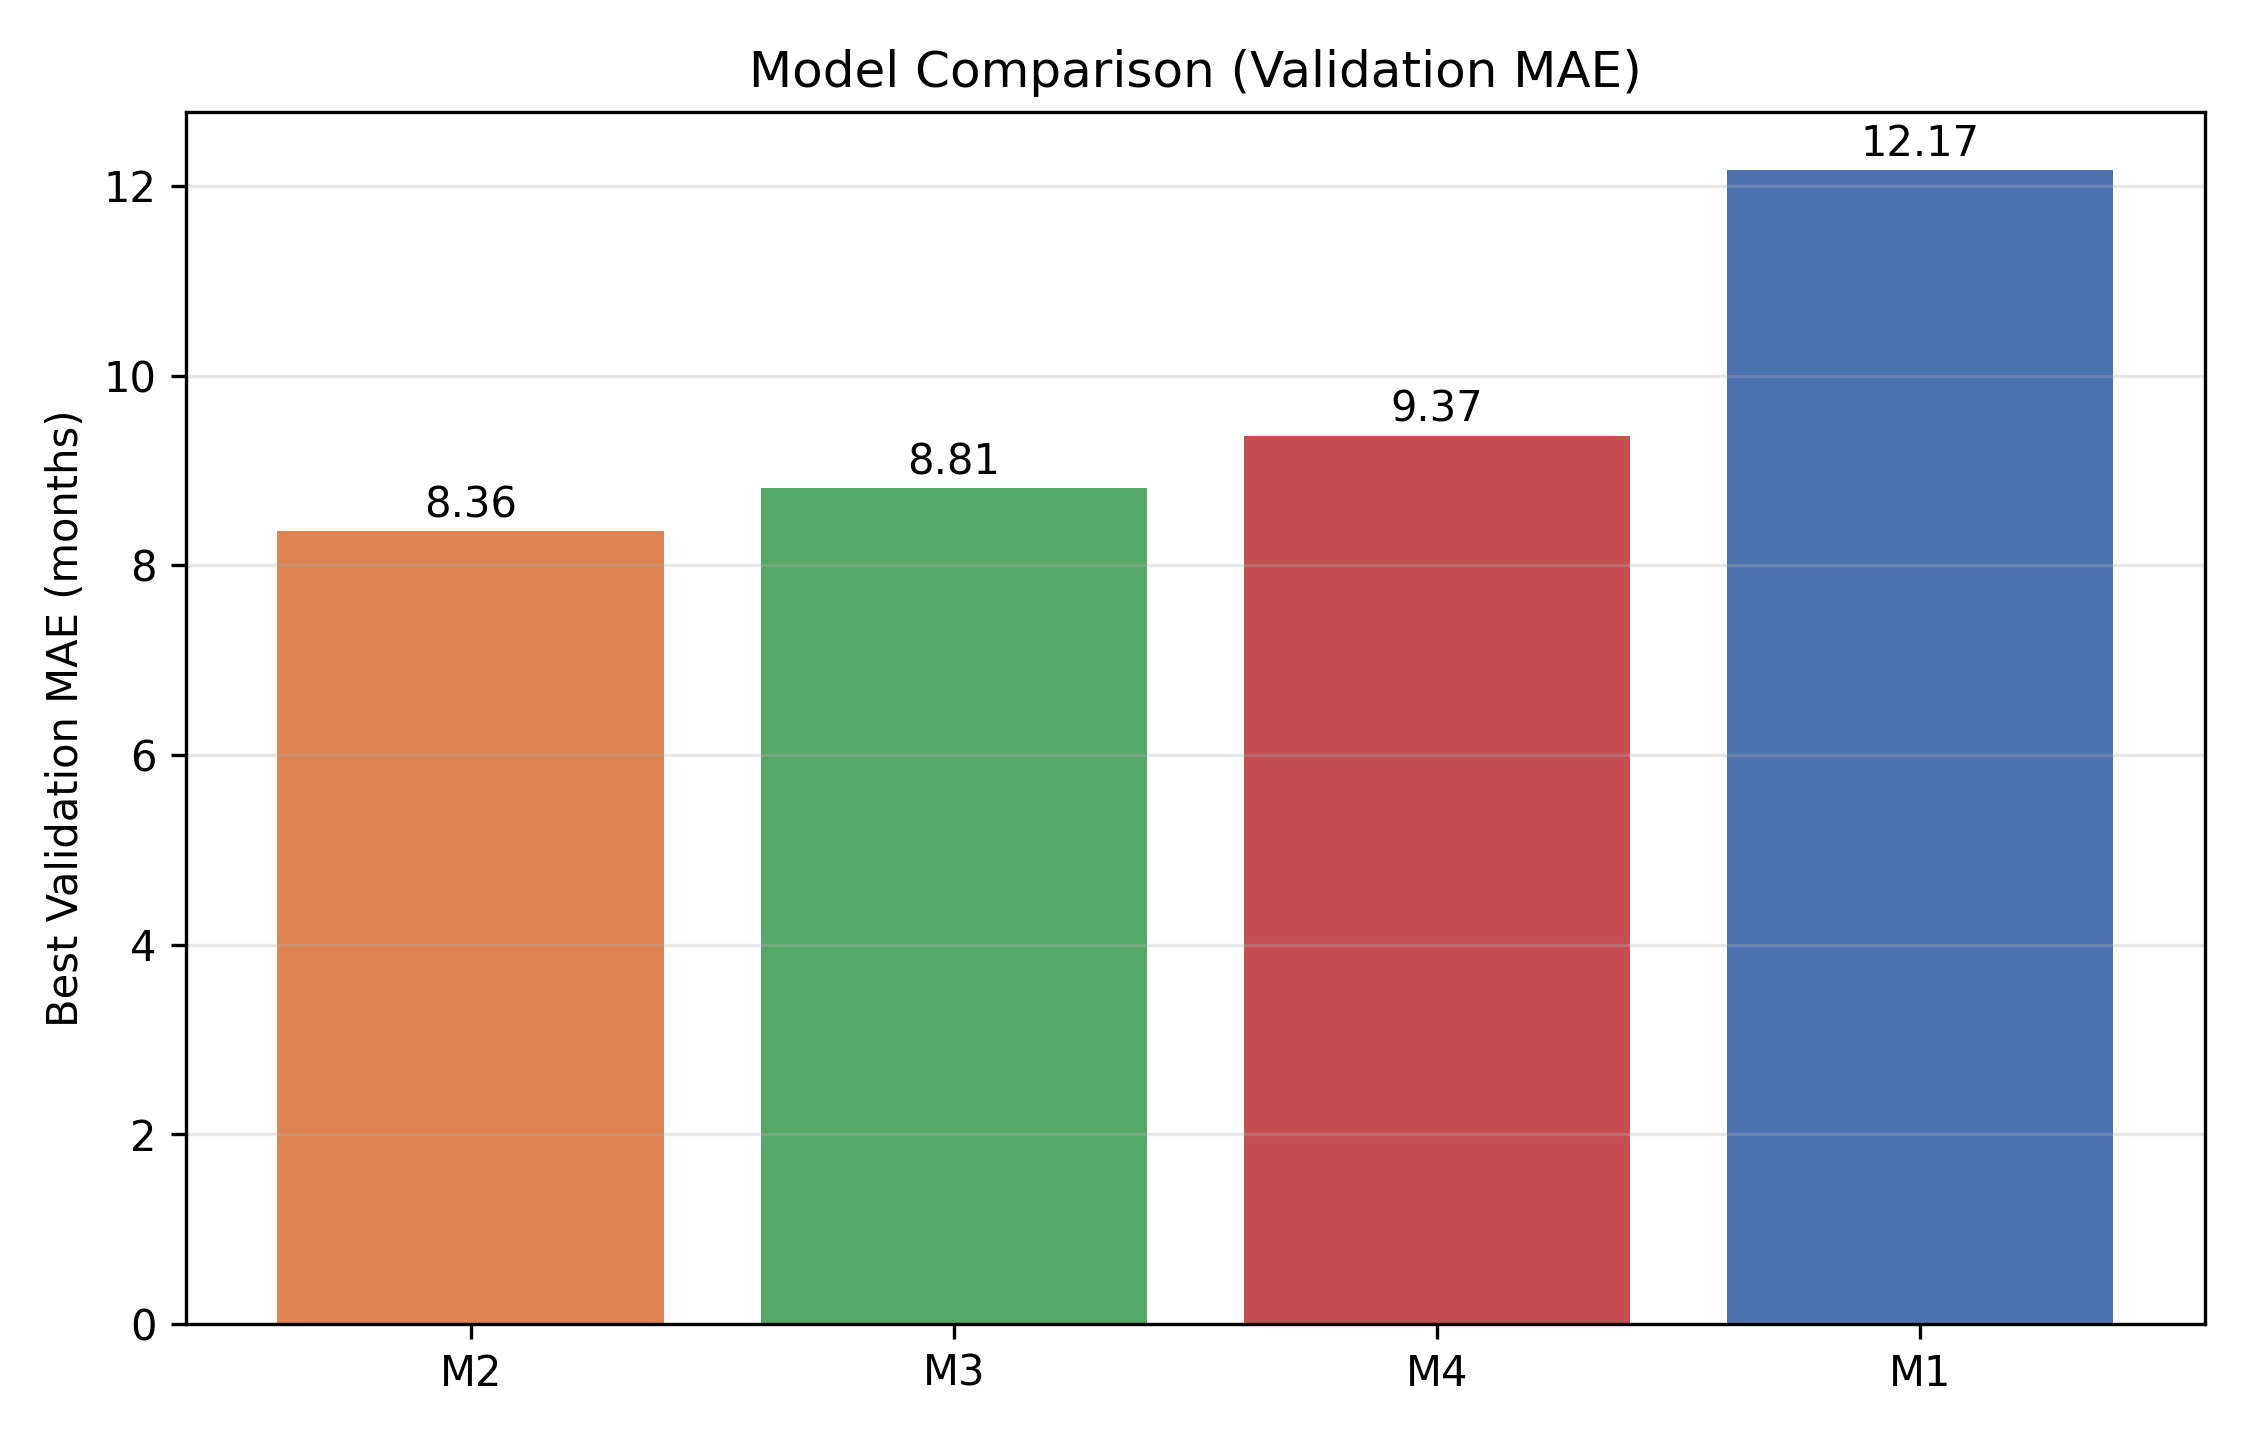

Saved: /kaggle/working/model_mae_bar.png
Summary table (sorted by validation MAE):


,model,val_mae_months,params,ms_per_img
0,M2_image_gender,8.360586,720529,1.720741
1,M3_patches_gated_gender,8.810433,786450,12.828202
2,M4_patches_learned_gender,9.367003,720786,12.768834
3,M1_image_only,12.170696,712273,1.600989


In [23]:
bar_path = "/kaggle/working/model_mae_bar.png"
plot_model_bar(summary_df, out_path=bar_path, style=PLOT_STYLE)
show_saved(bar_path)

print("Summary table (sorted by validation MAE):") 
display(summary_df.reset_index(drop=True))

## Error analysis (M2): MAE by gender and age bins

Saved: /kaggle/working/m2_mae_by_gender.png
Saved: /kaggle/working/m2_mae_by_age_bins.png


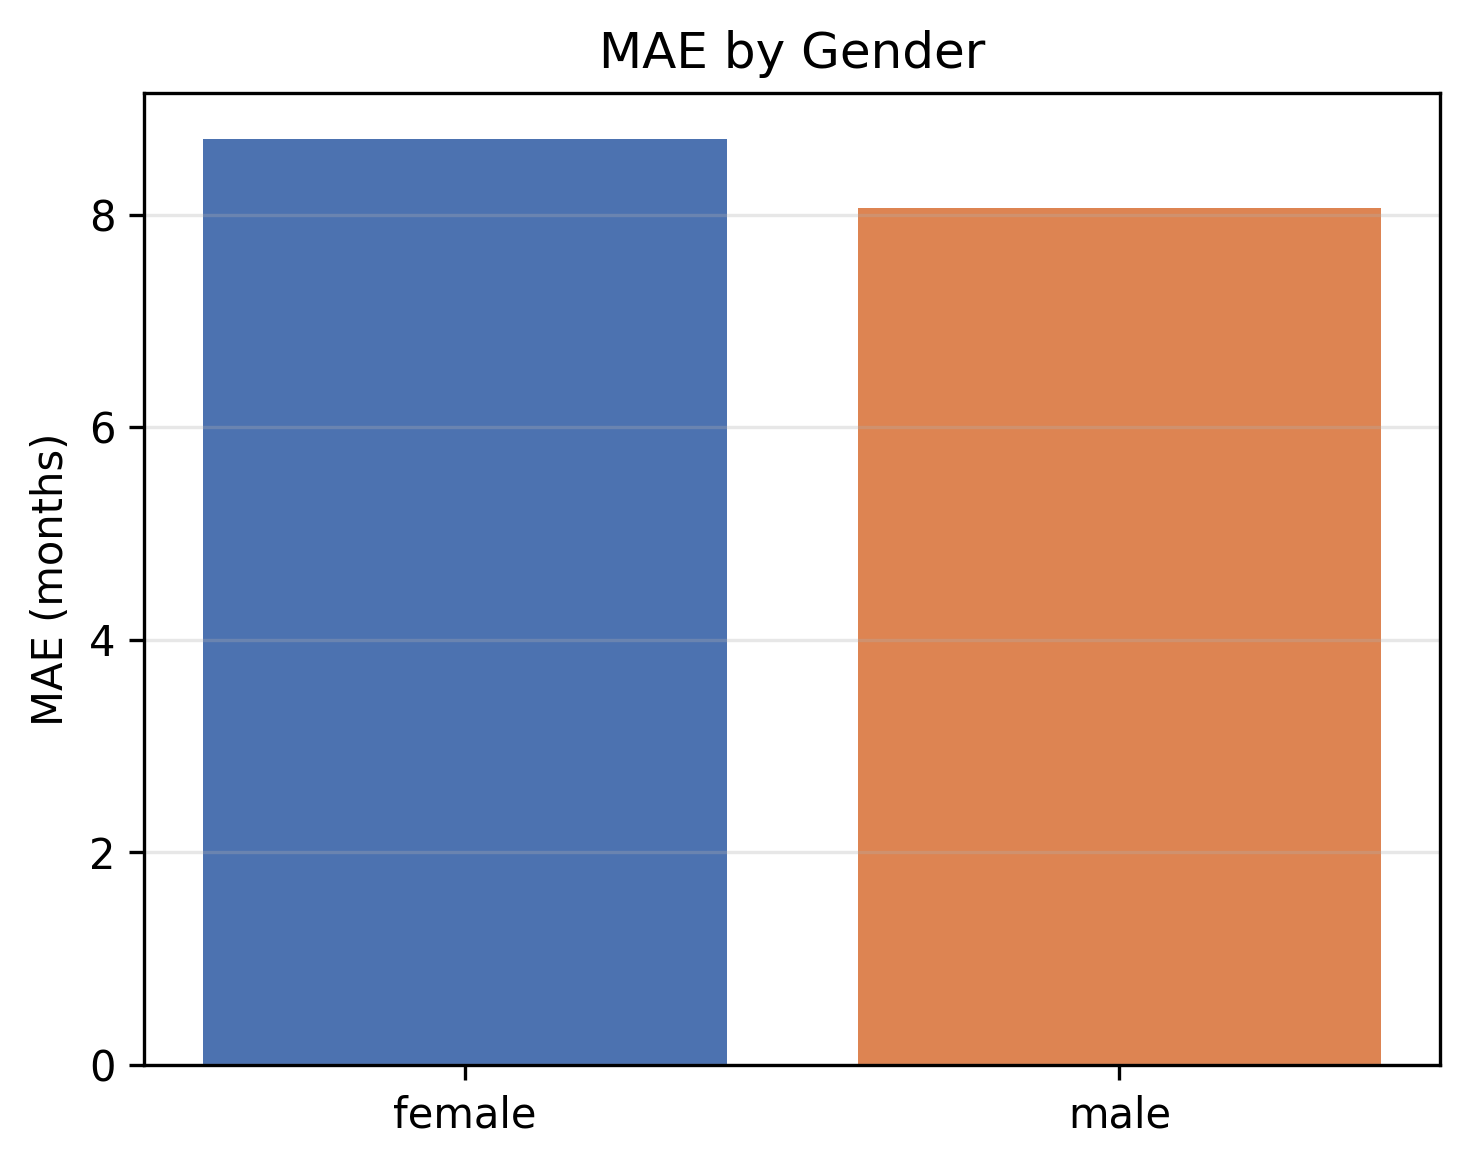

Saved: /kaggle/working/m2_mae_by_gender.png


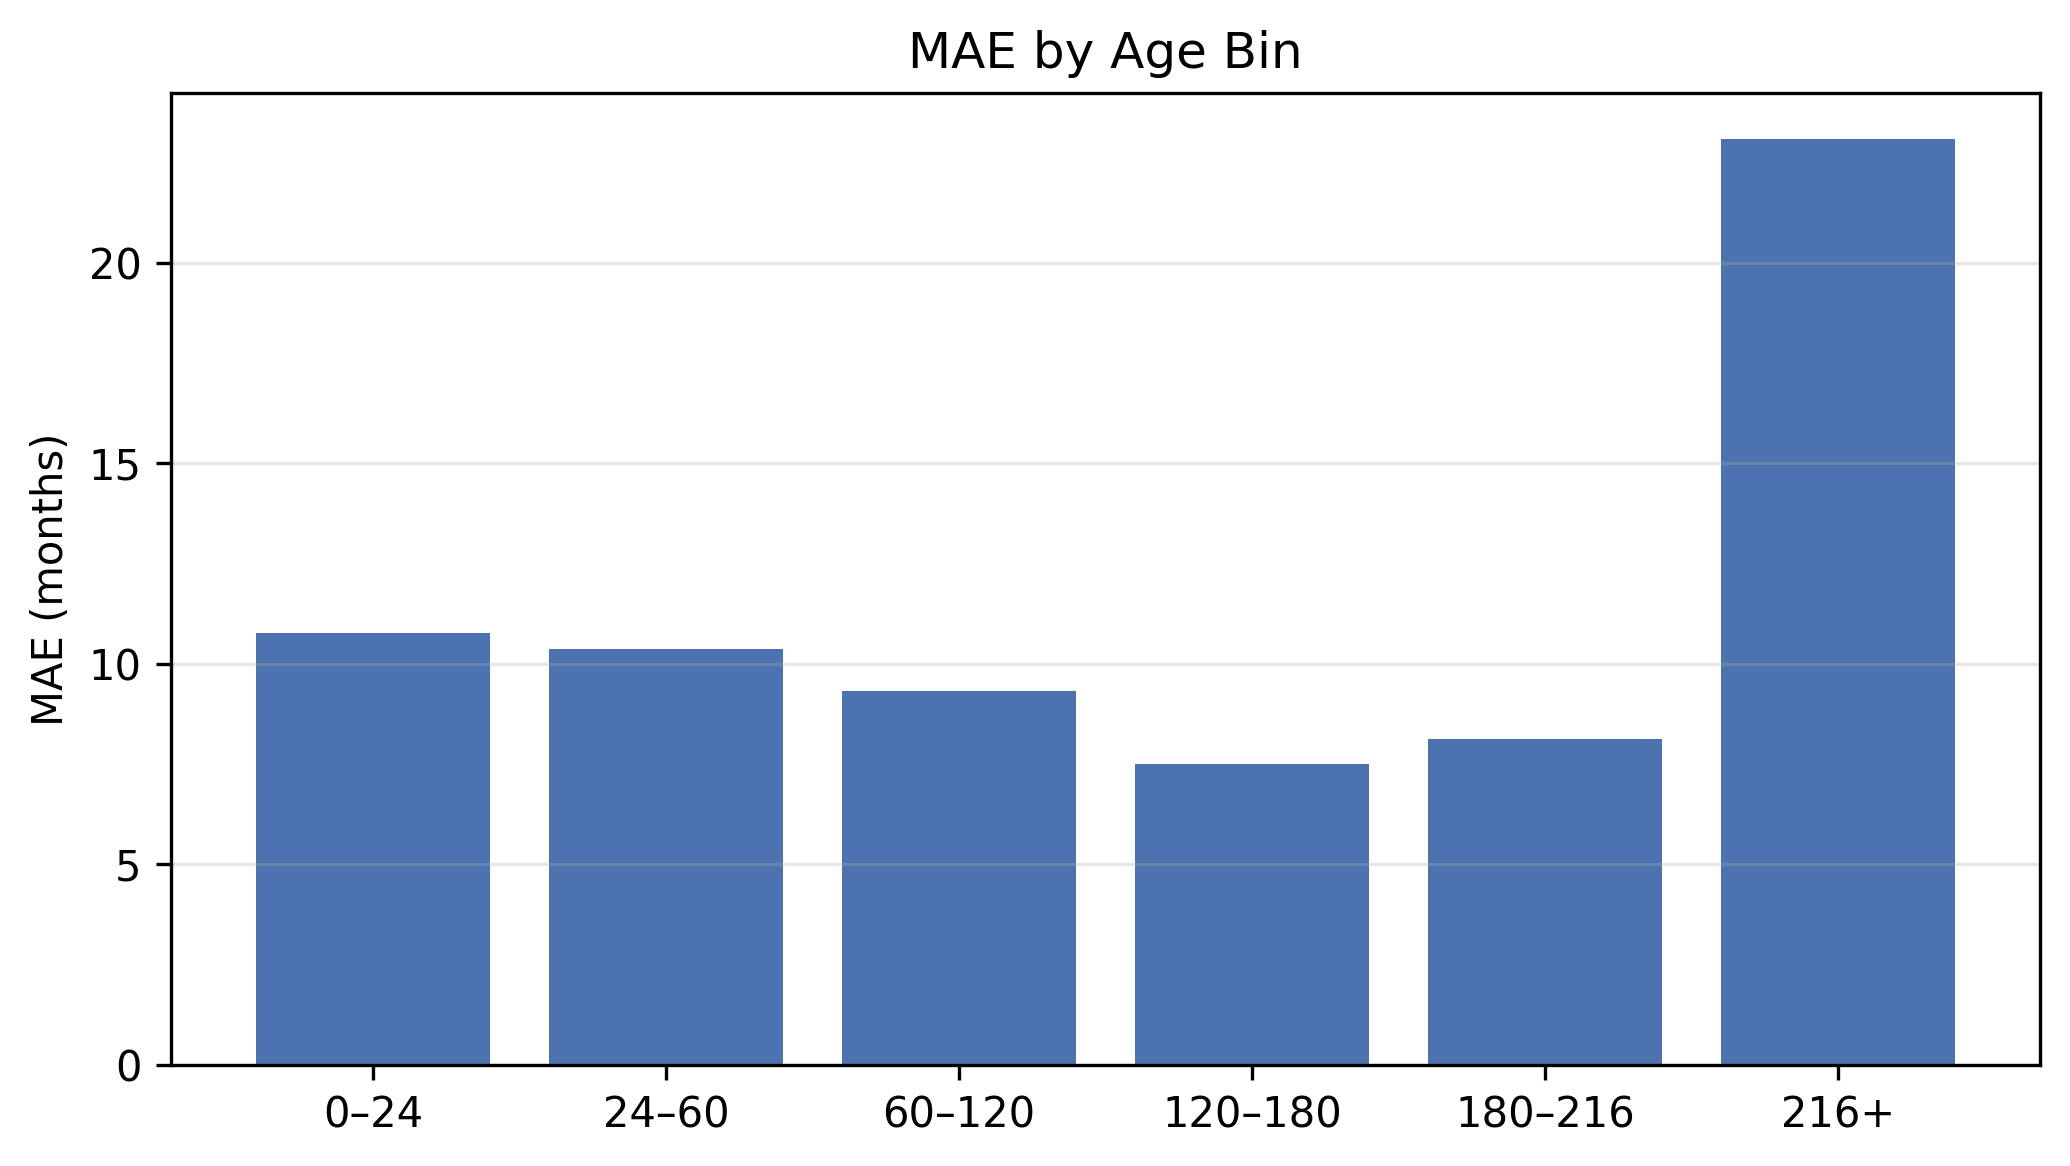

Saved: /kaggle/working/m2_mae_by_age_bins.png


In [24]:
root = "/kaggle/working/"
path_m2 = root + "m2_best.keras"

stats_m2 = run_error_analysis_for_model(
    model_path=path_m2,
    config_key="M2",
    df=val_df,
    out_prefix="/kaggle/working/m2"
)

show_saved("/kaggle/working/m2_mae_by_gender.png")
show_saved("/kaggle/working/m2_mae_by_age_bins.png")


## Qualitative examples (M4 by default)
#### Best / random / worst validation cases with GT, prediction, absolute error, and gender.

Saved: /kaggle/working/qualitative_examples.png


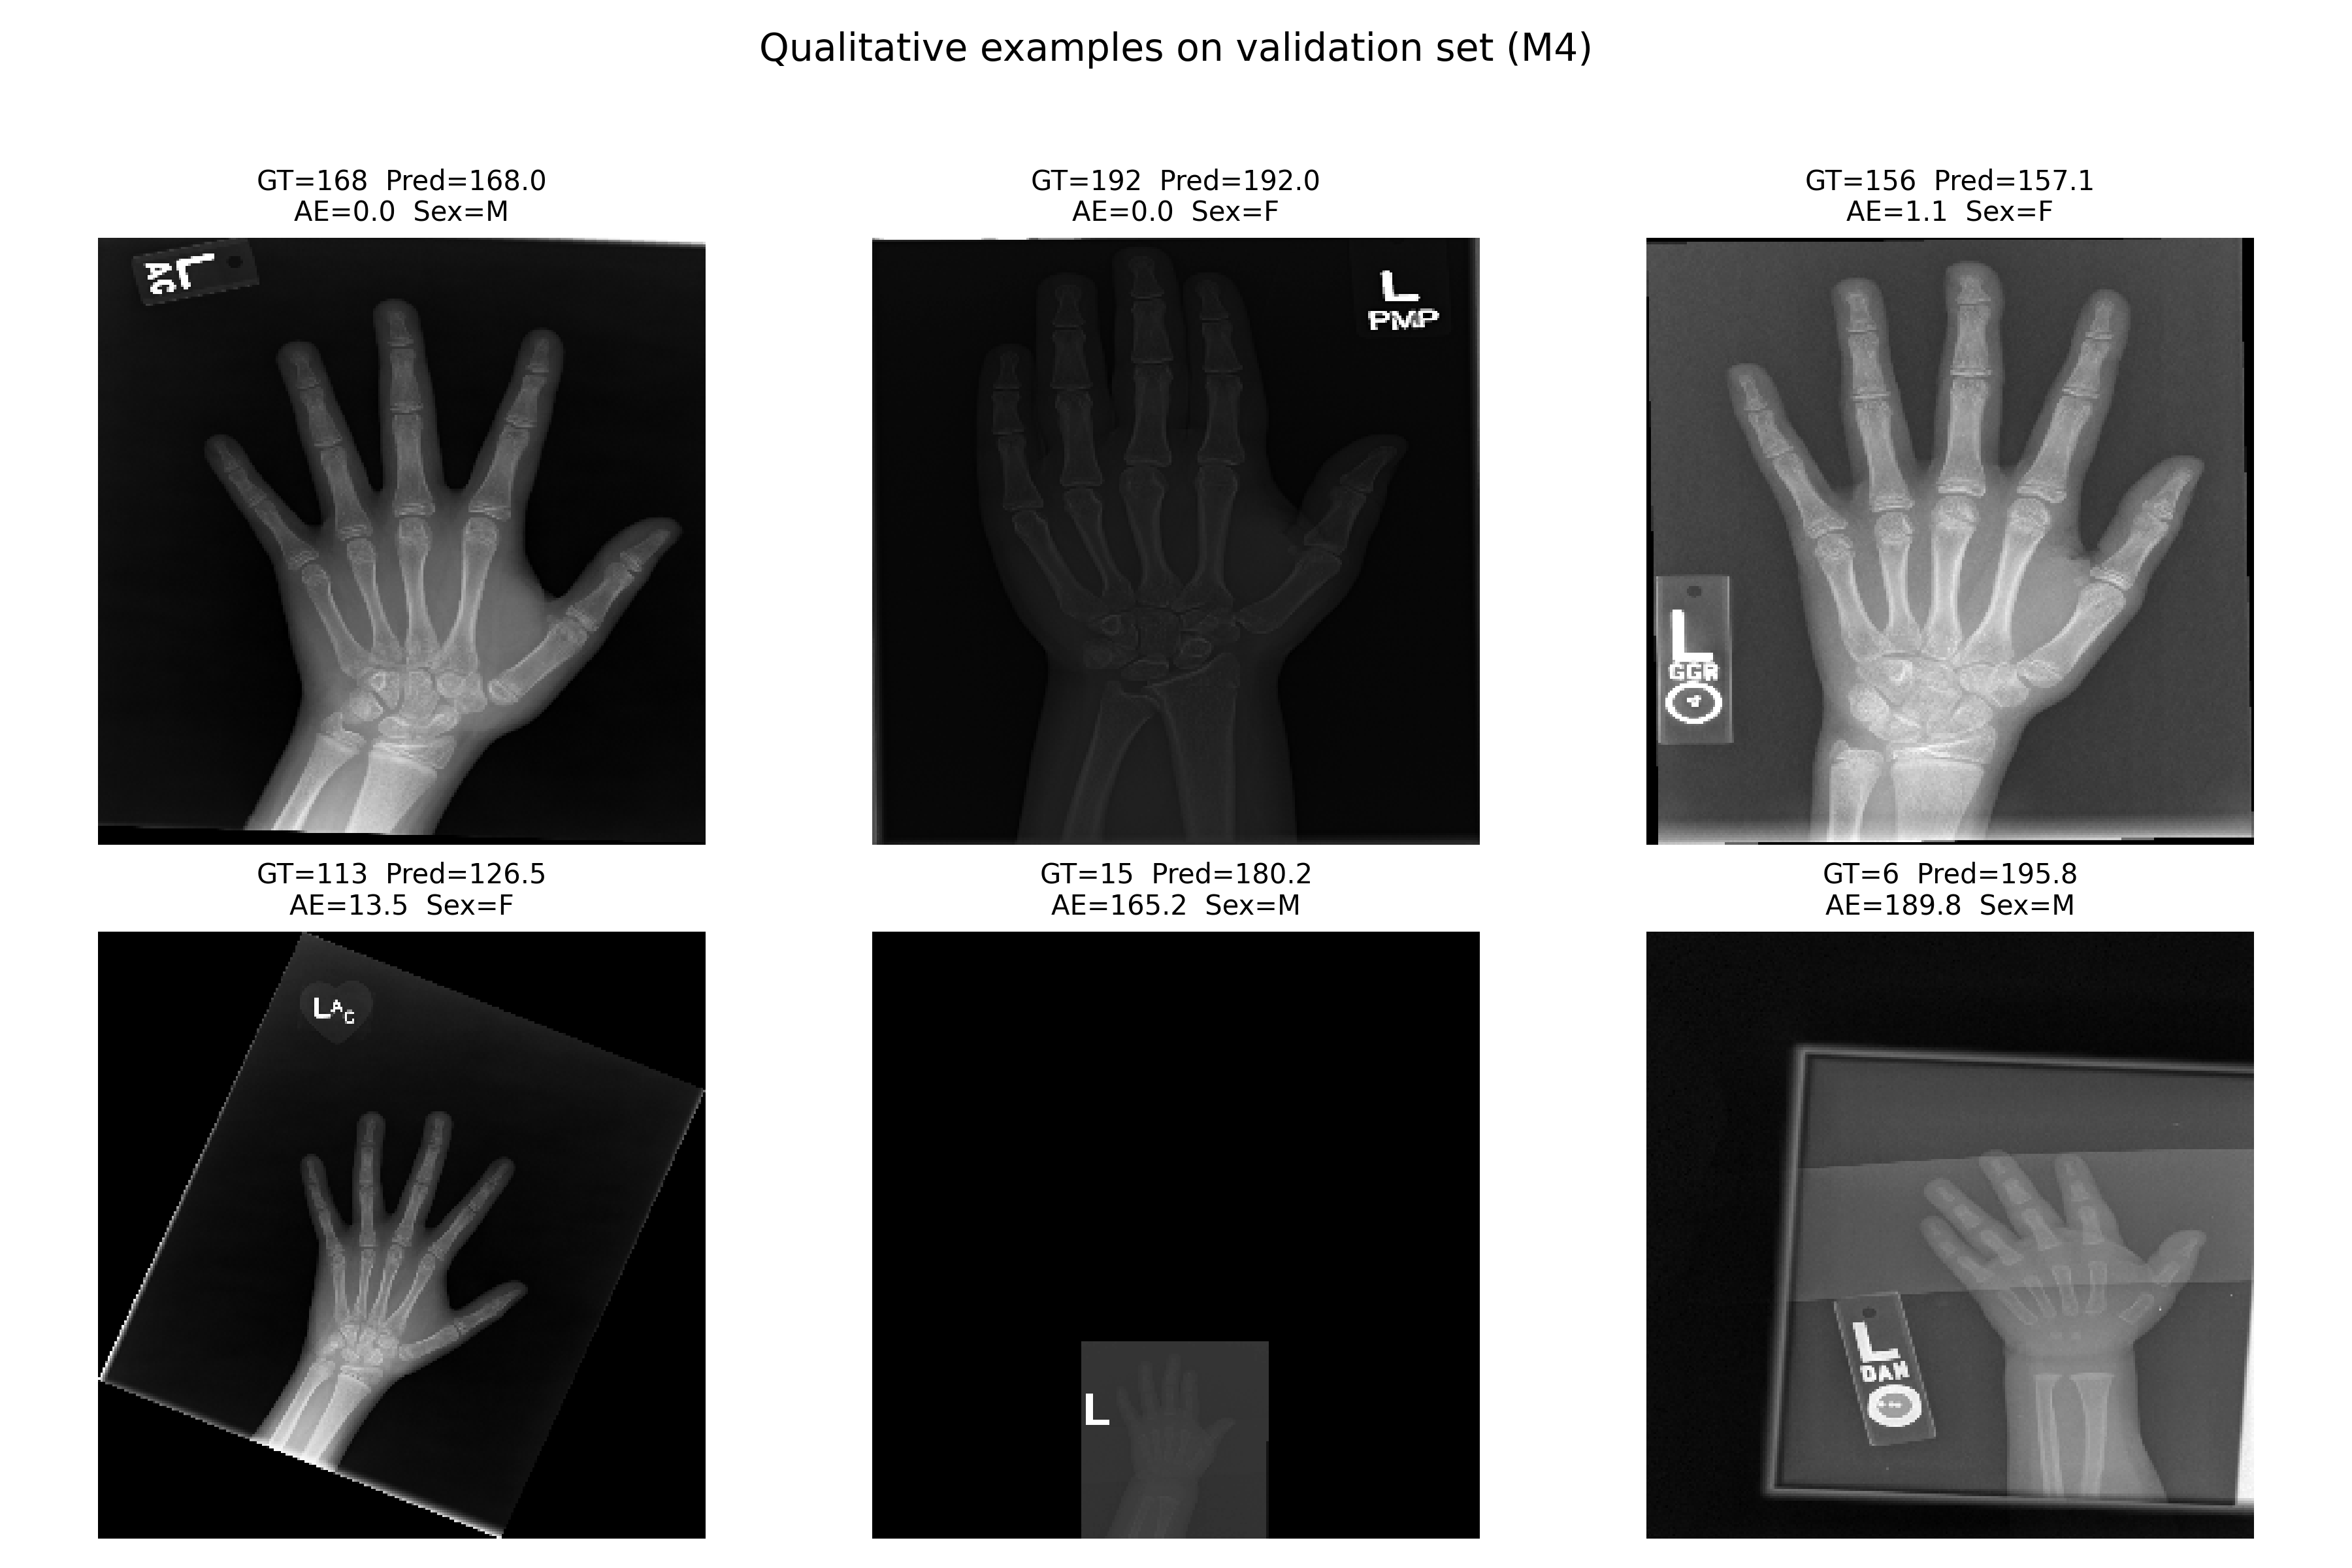

Saved: /kaggle/working/qualitative_examples.png


In [ ]:
CONFIG_KEY = "M4"
MODEL_PATH = "/kaggle/working/m4_best.keras"
OUT_PATH   = "/kaggle/working/qualitative_examples.png"
N_SHOW     = 6
BATCH      = 32

BINS = np.arange(Y_MIN, Y_MAX + 1, dtype=np.float32)  # [241]

best_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"GatedAttention": GatedAttention, "DLDLLoss": DLDLLoss, "DLDLMAE": DLDLMAE},
    compile=False
)

cfg = CONFIGS[CONFIG_KEY]
IMG_SIZE = cfg.img_size  

def decode_for_display_raw(path, img_size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [img_size, img_size], method="bilinear")
    img = tf.cast(img, tf.float32)
    img = tf.squeeze(img, axis=-1)
    img = (img - tf.reduce_min(img)) / (tf.reduce_max(img) - tf.reduce_min(img) + 1e-8)
    return img.numpy()

def decode_for_display_preprocessed(path, img_size=IMG_SIZE):
    """
    Show the SAME deterministic preprocessing used in training.
    Scales to [0,1] only for visualization.
    """
    img = preprocess_image(tf.constant(path)) 
    if img.shape[0] != img_size:
        img = tf.image.resize(img, [img_size, img_size])
    img = tf.squeeze(img, axis=-1)
    img = (img - tf.reduce_min(img)) / (tf.reduce_max(img) - tf.reduce_min(img) + 1e-8)
    return img.numpy()


def make_batch_inputs(paths, genders):
    """
    Build model inputs consistent with make_dataset() logic:
    - preprocess_image
    - resize to cfg.img_size
    - normalize by X_MEAN/X_STD
    - if patches: extract patches (patch_size/stride)
    """
    imgs = []
    for p in paths:
        img = preprocess_image(tf.constant(p)) 
        if cfg.img_size != IMG_SIZE:
            img = tf.image.resize(img, [cfg.img_size, cfg.img_size], method="bilinear")
        img = (img - tf.cast(X_MEAN, tf.float32)) / tf.cast(X_STD, tf.float32)
        imgs.append(img)
    imgs = tf.stack(imgs, axis=0)  # [B,H,W,1]

    x = {}

    if cfg.use_patches:
        # extract patches per image
        def extract_patches_single(img):
            img4 = tf.expand_dims(img, 0)
            patches = tf.image.extract_patches(
                images=img4,
                sizes=[1, cfg.patch_size, cfg.patch_size, 1],
                strides=[1, cfg.patch_stride, cfg.patch_stride, 1],
                rates=[1, 1, 1, 1],
                padding="VALID"
            )
            nH = tf.shape(patches)[1]
            nW = tf.shape(patches)[2]
            P = nH * nW
            return tf.reshape(patches, [P, cfg.patch_size, cfg.patch_size, 1])

        patches = tf.stack([extract_patches_single(imgs[i]) for i in range(imgs.shape[0])], axis=0)
        x["patches"] = patches
    else:
        x["img"] = imgs

    if cfg.use_gender:
        x["gender"] = tf.convert_to_tensor(np.asarray(genders).reshape(-1, 1), dtype=tf.float32)

    return x


def predict_months_for_paths(paths, genders):
    """
    DLDL decoding: logits -> softmax -> expectation over bins.
    """
    x = make_batch_inputs(paths, genders)
    logits = best_model.predict(x, verbose=0)              # [B,241]
    probs = tf.nn.softmax(logits, axis=1).numpy().astype(np.float32)
    return (probs * BINS[None, :]).sum(axis=1)

# Predict on validation
paths_all = val_df["path"].values
g_all = val_df["male"].values.astype(np.float32)
y_true_all = val_df["boneage"].values.astype(np.float32)

y_pred_all = np.zeros(len(val_df), dtype=np.float32)
for i in range(0, len(val_df), BATCH):
    p_batch = paths_all[i:i+BATCH].tolist()
    g_batch = g_all[i:i+BATCH]
    y_pred_all[i:i+BATCH] = predict_months_for_paths(p_batch, g_batch)

abs_err = np.abs(y_pred_all - y_true_all)
idx_sorted = np.argsort(abs_err)

rng = np.random.default_rng(SEED)
mid_pool = idx_sorted[2:-2]
rand_idxs = rng.choice(mid_pool, size=2, replace=False) if len(mid_pool) >= 2 else mid_pool[:2]

chosen = np.concatenate([idx_sorted[:2], rand_idxs, idx_sorted[-2:]])[:N_SHOW]

# Plot
plt.figure(figsize=(12, 8))
for j, idx in enumerate(chosen):
    ax = plt.subplot(2, 3, j+1)
    img = decode_for_display_raw(paths_all[idx], img_size=cfg.img_size)
    ax.imshow(img, cmap="gray")
    ax.axis("off")

    gt = float(y_true_all[idx])
    pr = float(y_pred_all[idx])
    ae = float(abs_err[idx])
    sex = "M" if int(g_all[idx]) == 1 else "F"

    ax.set_title(f"GT={gt:.0f}  Pred={pr:.1f}\nAE={ae:.1f}  Sex={sex}", fontsize=10)

plt.suptitle(f"Qualitative examples on validation set ({CONFIG_KEY})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUT_PATH, dpi=300)
plt.close()

print("Saved:", OUT_PATH)
show_saved(OUT_PATH)


## full image + 3 patch crops (NO OVERLAP)

Saved: /kaggle/working/patch_examples_triplet_clean.png


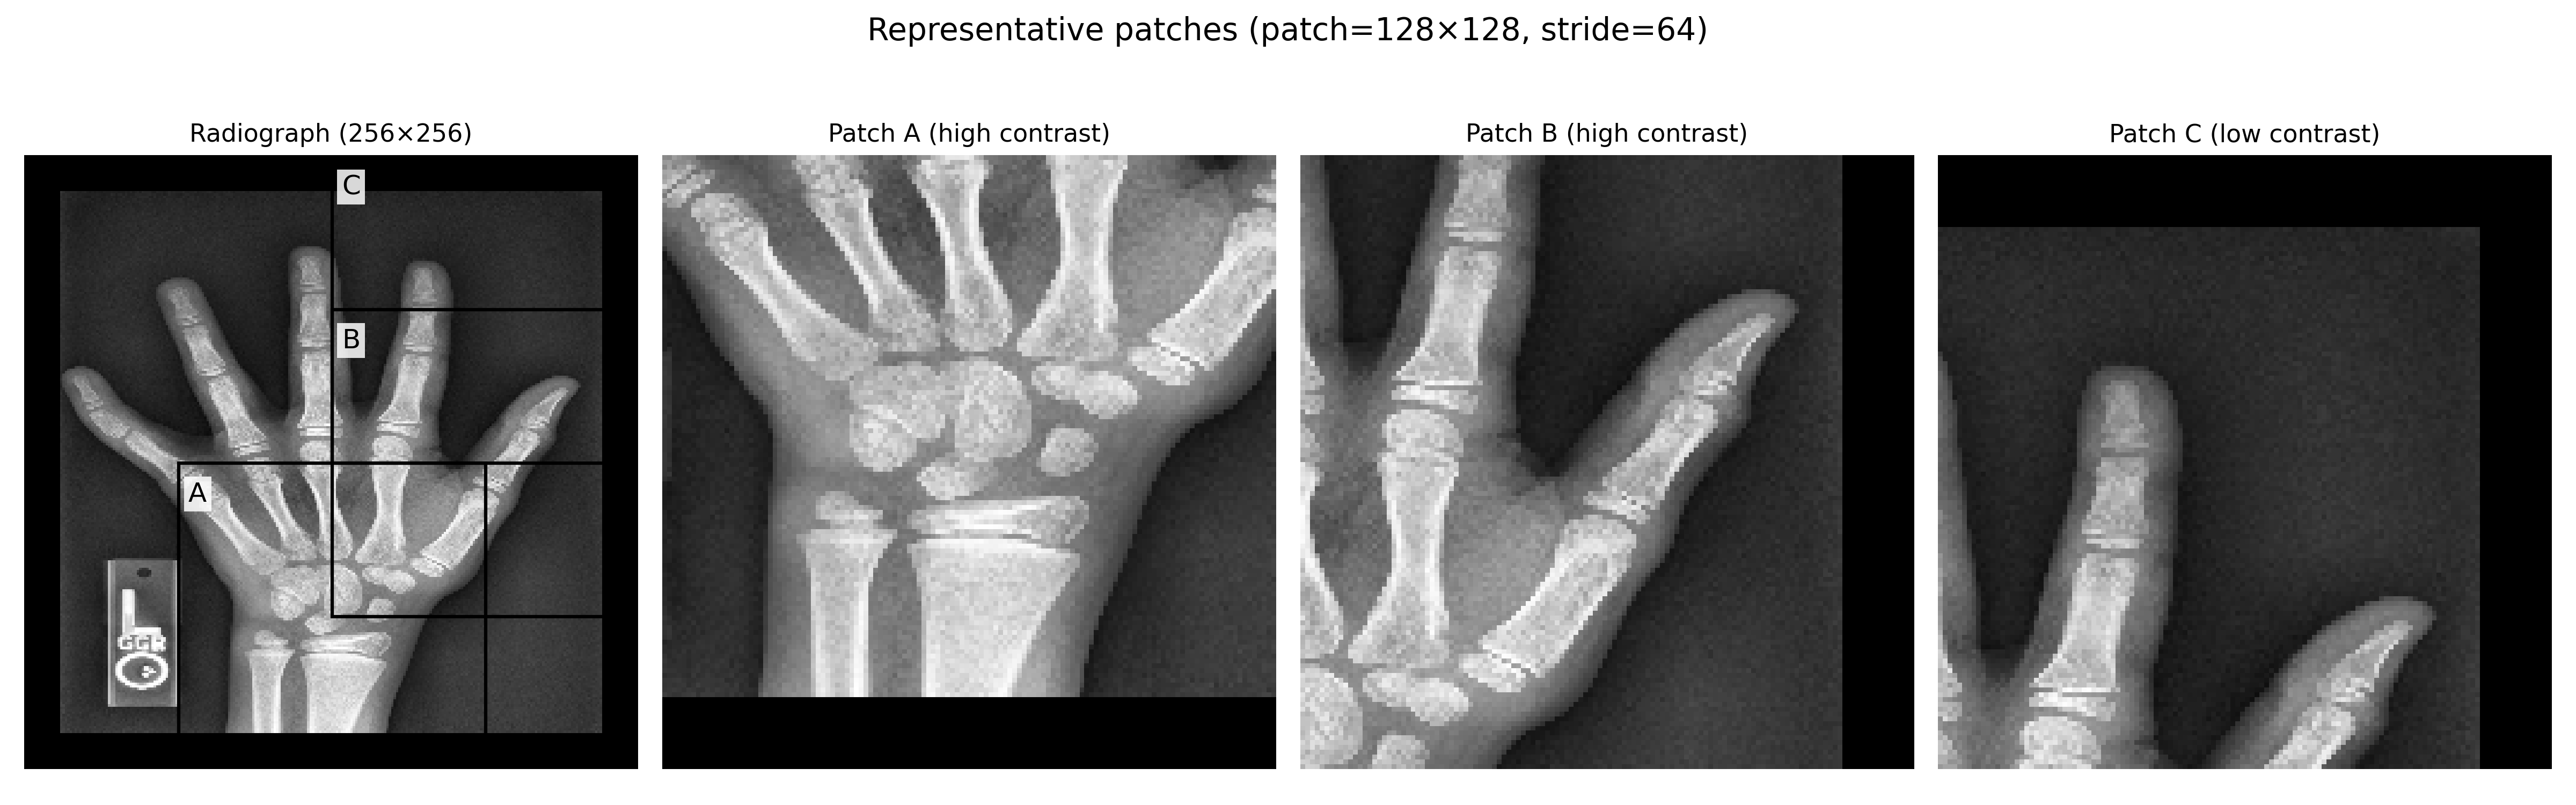

Saved: /kaggle/working/patch_examples_triplet_clean.png
Selected patch top-left coords (x,y): [(64, 128), (128, 64), (128, 0)]
Scores (std) for A,B,C: [0.28670215606689453, 0.25939828157424927, 0.19241438806056976]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf

OUT_PATH = "/kaggle/working/patch_examples_triplet_clean.png"

IMG_SIZE = 256
PATCH = 128
STRIDE = 64

IDX = 1363
img_path = val_df.iloc[IDX]["path"]

def decode_for_display_preprocessed(path):
    """
    Display version aligned with training preprocessing.
    Output is scaled to [0,1] only for visualization.
    """
    img = preprocess_image(tf.constant(path)) 
    img = tf.squeeze(img, axis=-1)            

    # Scale to [0,1] for display
    img = (img - tf.reduce_min(img)) / (tf.reduce_max(img) - tf.reduce_min(img) + 1e-8)
    return img.numpy()

img = decode_for_display_preprocessed(img_path)

ys = list(range(0, IMG_SIZE - PATCH + 1, STRIDE))
xs = list(range(0, IMG_SIZE - PATCH + 1, STRIDE))
grid_coords = [(x, y) for y in ys for x in xs]

def patch_score(img, x, y, patch=PATCH):
    p = img[y:y+patch, x:x+patch]
    return float(np.std(p))

scores = np.array([patch_score(img, x, y) for (x, y) in grid_coords], dtype=np.float32)
idx_sorted = np.argsort(scores)

# Low-contrast patch
low_idx = int(idx_sorted[0])

def overlap_area(a, b, patch=PATCH):
    ax, ay = a
    bx, by = b
    ix = max(0, min(ax+patch, bx+patch) - max(ax, bx))
    iy = max(0, min(ay+patch, by+patch) - max(ay, by))
    return ix * iy

# Choose 2 high-contrast patches with limited overlap
top_candidates = idx_sorted[::-1].tolist()
chosen_high = []
max_allowed_overlap = (PATCH * PATCH) * 0.25 

for idx in top_candidates:
    x, y = grid_coords[idx]
    if not chosen_high:
        chosen_high.append(idx)
    else:
        x0, y0 = grid_coords[chosen_high[0]]
        if overlap_area((x, y), (x0, y0)) <= max_allowed_overlap:
            chosen_high.append(idx)
    if len(chosen_high) == 2:
        break

# Fallback if overlap constraint too strict
if len(chosen_high) < 2:
    chosen_high = [int(idx_sorted[-1]), int(idx_sorted[-2])]

chosen_idxs = [chosen_high[0], chosen_high[1], low_idx]
labels = ["A (high contrast)", "B (high contrast)", "C (low contrast)"]

coords = []
patches = []
for idx in chosen_idxs:
    x, y = grid_coords[idx]
    coords.append((x, y))
    patches.append(img[y:y+PATCH, x:x+PATCH])

# Plot (1x4) 
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Full image with boxes
ax0 = axes[0]
ax0.imshow(img, cmap="gray")
ax0.axis("off")
ax0.set_title(f"Radiograph ({IMG_SIZE}×{IMG_SIZE})", fontsize=11)

for (x, y), lab in zip(coords, ["A", "B", "C"]):
    rect = mpatches.Rectangle((x, y), PATCH, PATCH, fill=False, linewidth=1.5)
    ax0.add_patch(rect)
    ax0.text(
        x + 4, y + 16, lab, fontsize=12,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2)
    )

# Patch crops
for i in range(3):
    ax = axes[i+1]
    ax.imshow(patches[i], cmap="gray")
    ax.axis("off")
    ax.set_title(f"Patch {labels[i]}", fontsize=11)

fig.suptitle(f"Representative patches (patch={PATCH}×{PATCH}, stride={STRIDE})", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(OUT_PATH, dpi=300)
plt.close(fig)

print("Saved:", OUT_PATH)
show_saved(OUT_PATH)

print("Selected patch top-left coords (x,y):", coords)
print("Scores (std) for A,B,C:", [float(scores[i]) for i in chosen_idxs])


## Visualization of learned patch weights for the patch-based model (M4).

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

BINS = np.arange(Y_MIN, Y_MAX + 1, dtype=np.float32)

def get_patches_tensor(img_tensor, patch_size, stride):
    """
    img_tensor: [H,W,1] float32 (already preprocessed + normalized)
    returns patches: [1, P, patch, patch, 1] and grid_h, grid_w
    """
    batch_img = tf.expand_dims(img_tensor, 0)  # [1,H,W,1]
    patches = tf.image.extract_patches(
        images=batch_img,
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, stride, stride, 1],
        rates=[1, 1, 1, 1],
        padding="VALID",
    )
    grid_h = patches.shape[1]
    grid_w = patches.shape[2]
    patches = tf.reshape(patches, (1, grid_h, grid_w, patch_size, patch_size, 1))
    patches = tf.reshape(patches, (1, -1, patch_size, patch_size, 1))  # [1,P,ph,pw,1]
    return patches, grid_h, grid_w

def predict_age_months_from_logits(logits_1x241: np.ndarray) -> float:
    probs = tf.nn.softmax(logits_1x241, axis=1).numpy().astype(np.float32)  # [1,241]
    return float((probs * BINS[None, :]).sum(axis=1)[0])

def plot_m4_learned_attention(model, df, sample_index=0, out_path=None,
                              img_size=256, patch_size=128, patch_stride=64):
    """
    Visualize learned patch weights for M4 (fusion_type='learned').
    """
    # build attention submodel
    try:
        attn_layer = model.get_layer("attn_softmax")
    except ValueError:
        raise ValueError("Layer 'attn_softmax' not found. This works only for M4 learned-attention model.")

    attn_model = tf.keras.Model(inputs=model.inputs, outputs=attn_layer.output)

    row = df.iloc[int(sample_index)]
    path = row["path"]
    true_age = float(row["boneage"])
    male = float(row["male"]) if "male" in row else 0.0

    # RAW DISPLAY IMAGE
    raw = tf.io.read_file(path)
    raw = tf.image.decode_png(raw, channels=1)
    raw = tf.image.resize(raw, [img_size, img_size], method="bilinear")
    raw_u8 = tf.cast(raw, tf.uint8).numpy()
    raw_rgb = cv2.cvtColor(raw_u8, cv2.COLOR_GRAY2RGB)

    # MODEL INPUT IMAGE (preprocessed + normalized)
    img = preprocess_image(tf.constant(path))  # includes CLAHE/mask/inpaint
    if img.shape[0] != img_size:
        img = tf.image.resize(img, [img_size, img_size], method="bilinear")
    img_norm = (img - tf.cast(X_MEAN, tf.float32)) / tf.cast(X_STD, tf.float32)

    # patches
    patches, grid_h, grid_w = get_patches_tensor(img_norm, patch_size, patch_stride)

    # inputs dict (match model signature)
    inputs = {"patches": patches}
    input_names = [t.name.split(":")[0] for t in model.inputs]
    if any("gender" in n for n in input_names):
        inputs["gender"] = tf.constant([[male]], dtype=tf.float32)

    # prediction + attention weights
    logits = model.predict(inputs, verbose=0)          # [1,241]
    pred_age = predict_age_months_from_logits(logits)

    w = attn_model.predict(inputs, verbose=0)          # [1,P,1]
    w = np.asarray(w).reshape(-1)                      # [P]
    if w.size != grid_h * grid_w:
        raise ValueError(f"Attention size mismatch: got P={w.size}, expected {grid_h*grid_w}")

    # normalize weights to [0,1] for visualization
    w_grid = w.reshape(grid_h, grid_w)
    w_norm = (w_grid - w_grid.min()) / (w_grid.max() - w_grid.min() + 1e-8)

    # upscale to image size + colorize
    heat_up = cv2.resize(w_norm, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    heat_color = cv2.applyColorMap((255 * heat_up).astype(np.uint8), cv2.COLORMAP_JET)
    heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(raw_rgb, 0.60, heat_color, 0.40, 0)

    # plot
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(raw_rgb)
    plt.title(f"Raw image\nGT: {true_age:.0f}m | Pred: {pred_age:.1f}m | Sex: {'M' if male>=0.5 else 'F'}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f"Learned patch weights (M4)\nGrid: {grid_h}×{grid_w}, patch={patch_size}, stride={patch_stride}")
    plt.axis("off")

    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print("Saved:", out_path)

    plt.show()

    return w_grid 


Saved: /kaggle/working/m4_learned_attention.png


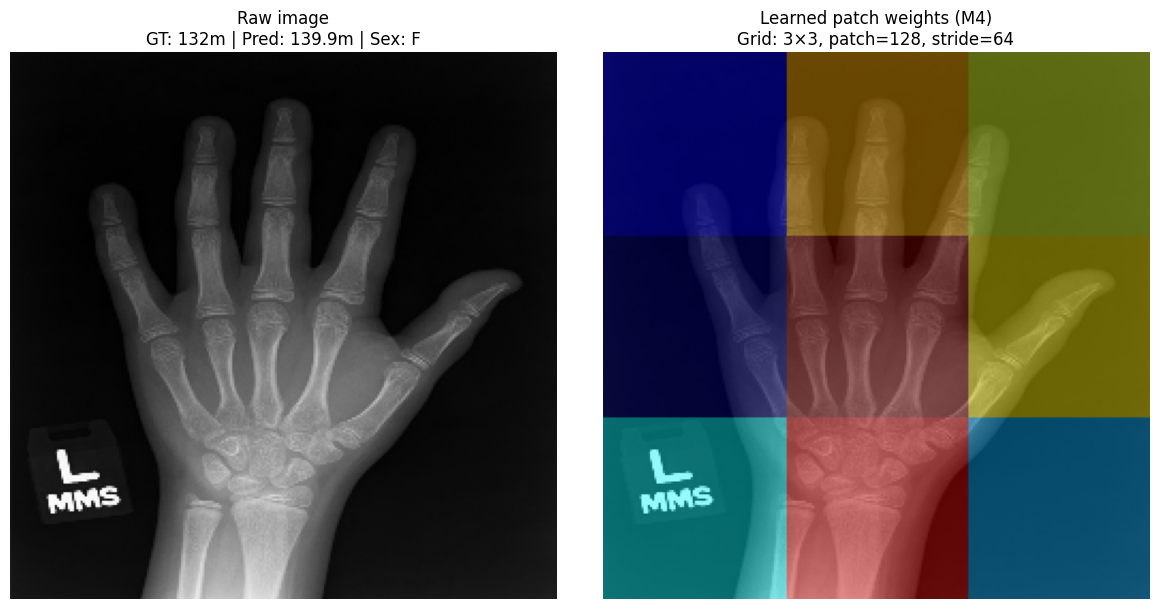

In [ ]:
m4_path = root + "/m4_best.keras"
model_m4 = tf.keras.models.load_model(
    m4_path,
    custom_objects={"DLDLLoss": DLDLLoss, "DLDLMAE": DLDLMAE, "GatedAttention": GatedAttention},
    compile=False
)

w_grid = plot_m4_learned_attention(
    model_m4, val_df, sample_index=987,
    out_path="/kaggle/working/m4_learned_attention.png",
    img_size=256, patch_size=128, patch_stride=64
)

Saved: /kaggle/working/preprocess_before_after.png


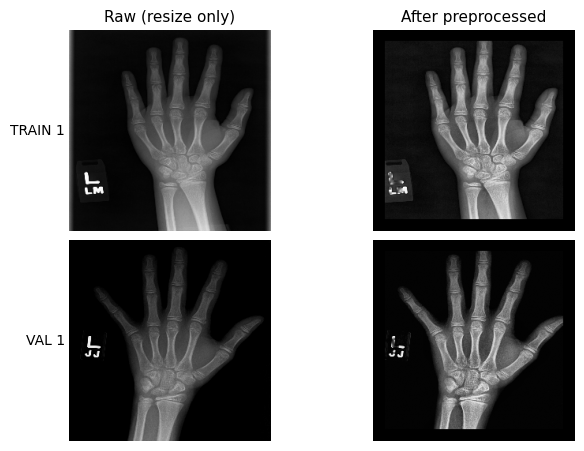

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def show_before_after_clean(train_df, val_df, n=2, seed=SEED-6, savepath=None, img_size=IMG_SIZE):
    # sample
    tr = train_df.sample(n=min(n, len(train_df)), random_state=seed).reset_index(drop=True)
    va = val_df.sample(n=min(n, len(val_df)), random_state=seed+1).reset_index(drop=True)

    fig, axes = plt.subplots(2*len(tr), 2, figsize=(6.2, 2.2*(2*len(tr))), constrained_layout=True)

    # column headers
    axes[0,0].set_title("Raw (resize only)", fontsize=11)
    axes[0,1].set_title("After preprocessed", fontsize=11)

    def draw_rows(df, row0, label):
        for i, p in enumerate(df["path"].values):
            raw = load_raw_image(p, img_size=img_size).numpy()
            pre = preprocess_image(tf.constant(p)).numpy() 

            raw_u8 = to_uint8(raw[..., 0])
            pre_u8 = to_uint8(pre[..., 0])

            r = row0 + i
            axes[r,0].imshow(raw_u8, cmap="gray"); axes[r,0].axis("off")
            axes[r,1].imshow(pre_u8, cmap="gray"); axes[r,1].axis("off")

            # left-side row label
            axes[r,0].text(
                -0.02, 0.5, f"{label} {i+1}",
                transform=axes[r,0].transAxes,
                va="center", ha="right", fontsize=10
            )

    draw_rows(tr, 0, "TRAIN")
    draw_rows(va, len(tr), "VAL")

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        print("Saved:", savepath)

    plt.show()

show_before_after_clean(train_df, val_df, n=1, savepath="/kaggle/working/preprocess_before_after.png")
